# 5.2 Stage 1.5 & Stage 2: Feature Enrichment -> Cost Prediction

**Pipeline:** Stage 0 (Feature Engineering) -> Stage 1 (2D Classification, 10-class) -> **Stage 1.5 (Feature Enrichment)** -> **Stage 2 (Cost Prediction)**

**Stage 1.5 rationale:** Stage 1 classifies patients into 10 transition-aware classes. Within each class, costs still vary. Stage 1.5 enriches with:
- **ENGAGEMENT_SCORE**: Utilization pattern (proactive vs crisis-oriented care)
- **ESCALATION_MAGNITUDE**: Predicted cost-bin movement (`DELTA_BIN` regression)
- **Raw Rx timeline features**: `RX_DENSITY`, `RX_GAP_RATIO`, `RX_TRAILING_GAP`, `RX_REGULARITY`

**Stage 2 approach:**
- Train class-specific regressors using true training labels.
- Route inference-time predictions by **Stage 1 predicted class** (`STAGE1_PRED_CLASS`), not true class labels.
- Use a global model as fallback for classes without a stable class-specific model.

## Data Leakage Prevention
- All features use **Year 1 data only**
- Stage 1 tier probabilities generated via **out-of-fold** prediction
- Stage 1.5 latent factors use **cross-validated** predictions
- Train/val/test split is **stratified by panel** (7:2:1)


In [1]:
# SETUP & IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json

# Sklearn imports
from sklearn.model_selection import (
    train_test_split, cross_val_predict, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LogisticRegression, TweedieRegressor, Ridge
)
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    StackingClassifier, StackingRegressor
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, accuracy_score, mean_squared_error, mean_absolute_error,
    r2_score
)

# XGBoost
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
np.random.seed(42)

STAGE2_NOTEBOOK_VERSION = 'stage2_softroute_v2026_03_17_r1'

# Paths (robust to repo root or notebooks cwd)
CWD = Path.cwd()
if (CWD / 'data' / 'processed_v2').exists():
    REPO_ROOT = CWD
elif (CWD.parent / 'data' / 'processed_v2').exists():
    REPO_ROOT = CWD.parent
else:
    REPO_ROOT = CWD

DATA_PATH = REPO_ROOT / 'data' / 'processed_v2' / 'model_ready_stage1.parquet'
DATA_PATH_BACKUP = REPO_ROOT / 'data' / 'processed_v2' / 'model_ready_v2.parquet'
REPORT_DIR = REPO_ROOT / 'reports'
(REPORT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
(REPORT_DIR / 'tables').mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Stage2 notebook version: {STAGE2_NOTEBOOK_VERSION}")
print(f"Repo root: {REPO_ROOT}")
print(f"Primary input: {DATA_PATH}")

Setup complete.
Stage2 notebook version: stage2_softroute_v2026_03_17_r1
Repo root: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo
Primary input: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/data/processed_v2/model_ready_stage1.parquet


---
## 1. Load Data from Stage 1

In [2]:
# Try to load Stage 1 output; fallback to base processed data
if DATA_PATH.exists():
    df = pd.read_parquet(DATA_PATH)
    print(f"Loaded Stage 1 output: {DATA_PATH}")
    has_stage1_output = 'LATENT_RISK_SCORE' in df.columns
else:
    df = pd.read_parquet(DATA_PATH_BACKUP)
    print(f"Loaded base processed data: {DATA_PATH_BACKUP}")
    has_stage1_output = False

CLASS_NAMES = {
    0: 'Low_Improve',   1: 'Low_Stable',    2: 'Low_MildRise',  3: 'Low_Jumper',
    4: 'Mid_Improve',   5: 'Mid_Stable',    6: 'Mid_Escalate',
    7: 'High_Improve',  8: 'High_Stable',   9: 'High_Escalate',
}

print(f"\nDataset: {len(df):,} rows, {len(df.columns)} columns")
print(f"Stage 1 Latent Factors Available: {has_stage1_output}")

print(f"\nColumns: {list(df.columns)}")

Loaded Stage 1 output: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/data/processed_v2/model_ready_stage1.parquet

Dataset: 60,602 rows, 73 columns
Stage 1 Latent Factors Available: True

Columns: ['DUPERSID', 'PANEL', 'START_YEAR', 'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG', 'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2', 'Y1_BIN', 'Y2_BIN', 'DELTA_BIN', 'Y1_LEVEL', 'RISK_TIER', 'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER', 'PROB_LOW_IMPROVE', 'P_LOW_IMPROVE', 'PROB_LOW_STABLE', 'P_LOW_STABLE', 'PROB_LOW_MILDRISE', 'P_LOW_MILDRISE', 'PROB_LOW_JUMPER', 'P_LOW_JUMPER', 'PROB_MID

---
# STAGE 1.5: Feature Enrichment

Stage 1.5 keeps only enrichment variables that add signal beyond original Year 1 features and Stage 1 latent outputs.

**Kept modules:**
- 1.5B: `ENGAGEMENT_SCORE` (direct utilization-pattern construct)
- 1.5C: `ESCALATION_MAGNITUDE` (OOF regression on `DELTA_BIN`)
- 1.5E: Raw Rx timeline variables (`RX_DENSITY`, `RX_GAP_RATIO`, `RX_TRAILING_GAP`, `RX_REGULARITY`)

**Removed from prior versions:**
- `PROB_CRISIS_MODE`, `ESCALATION_SCORE`, `HAZARD_DISCONTINUE` (high redundancy with existing features/Stage 1 outputs)

| Factor | What it captures | Method | Input variables |
|--------|------------------|--------|-----------------|
| `ENGAGEMENT_SCORE` | Proactive vs crisis care pattern | Direct formula | `UTIL_ER_Y1`, `UTIL_OB_Y1`, `UTIL_IP_Y1` |
| `ESCALATION_MAGNITUDE` | Expected bin movement | 5-fold OOF regression | Clinical/utilization + `COST_Y1_ADJ` + engagement |
| `RX_*` timeline | Fill consistency and gaps | Direct extraction | Prescribed medicines timeline |

---
## Stage 1.5B: Healthcare Engagement Score

**What:** Composite score measuring whether a patient's Y1 care pattern is proactive (regular office visits) or reactive/crisis-oriented (ER/IP dependent).

**Formula:** `ENGAGEMENT_SCORE = Norm(Office) - Norm(ER_ratio) - 0.5 * Norm(IP)`, range approximately `[-1, 1]`.

Higher score = more office-centered care pattern; lower score = more ER/IP-centered pattern.

In [3]:
# STAGE 1.5B: Healthcare Engagement Score (Direct Calculation)
#
# Methodology: No predict_proba needed - directly calculate from Y1 data
# 
# ENGAGEMENT_SCORE = Composite metric, range [-1, 1]:
#   +1 = Very proactive (high office visits, low ER)
#   -1 = Crisis-oriented (high ER/IP, low office)
#

print("STAGE 1.5B: Healthcare Engagement Score (Direct Calculation)")

# Calculate Engagement Score directly from Y1 utilization data
if all(c in df.columns for c in ['UTIL_ER_Y1', 'UTIL_OB_Y1', 'UTIL_IP_Y1']):
    
    # --- Normalization function ---
    def normalize_0_1(series):
        """Min-max normalize to [0, 1]"""
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return series * 0
        return (series - min_val) / (max_val - min_val)
    
    # --- Calculate components ---
    
    # 1. ER dependency: ER / (ER + Office + 1), high=bad
    total_visits = df['UTIL_ER_Y1'] + df['UTIL_OB_Y1'] + 1
    er_dependency = df['UTIL_ER_Y1'] / total_visits
    er_score = normalize_0_1(er_dependency)
    
    # 2. IP intensity: hospitalization=high risk, high=bad
    ip_score = normalize_0_1(df['UTIL_IP_Y1'].clip(upper=5))  # cap at 5
    
    # 3. Office engagement: moderate=good, but too many may indicate issues
    ob_optimal = df['UTIL_OB_Y1'].clip(upper=df['UTIL_OB_Y1'].quantile(0.9))
    ob_score = normalize_0_1(ob_optimal)
    
    # --- Calculate Engagement Score ---
    # Formula: Office(+) - ER_dependency(-) - IP_intensity(-)
    raw_score = ob_score - er_score - ip_score * 0.5
    
    # Normalize to [-1, 1]
    df['ENGAGEMENT_SCORE'] = raw_score / max(raw_score.abs().max(), 0.001)
    
    # --- Classification (for visualization only) ---
    def classify_engagement(score):
        if score > 0.3:
            return 'Proactive'
        elif score < -0.3:
            return 'Crisis-Mode'
        else:
            return 'Reactive'
    
    df['ENGAGEMENT_TYPE'] = df['ENGAGEMENT_SCORE'].apply(classify_engagement)
    
    # --- Output ---
    print(f"\n=== Engagement Score (Direct Calculation) ===")
    print(f"Formula: Score = Normalized(Office) - Normalized(ER_ratio) - 0.5×Normalized(IP)")
    print(f"\nStatistics:")
    print(f"  Mean:   {df['ENGAGEMENT_SCORE'].mean():.3f}")
    print(f"  Std:    {df['ENGAGEMENT_SCORE'].std():.3f}")
    print(f"  Range:  [{df['ENGAGEMENT_SCORE'].min():.3f}, {df['ENGAGEMENT_SCORE'].max():.3f}]")
    
    print(f"\nEngagement Type Distribution:")
    for t in ['Proactive', 'Reactive', 'Crisis-Mode']:
        n = (df['ENGAGEMENT_TYPE'] == t).sum()
        print(f"  {t}: {n:,} ({n/len(df)*100:.1f}%)")
    
else:
    print("⚠ Utilization columns not available. Setting ENGAGEMENT_SCORE = 0")
    df['ENGAGEMENT_SCORE'] = 0.0
    df['ENGAGEMENT_TYPE'] = 'Unknown'

STAGE 1.5B: Healthcare Engagement Score (Direct Calculation)



=== Engagement Score (Direct Calculation) ===
Formula: Score = Normalized(Office) - Normalized(ER_ratio) - 0.5×Normalized(IP)

Statistics:
  Mean:   0.151
  Std:    0.236
  Range:  [-1.000, 0.667]

Engagement Type Distribution:
  Proactive: 12,960 (21.4%)
  Reactive: 45,857 (75.7%)
  Crisis-Mode: 1,785 (2.9%)


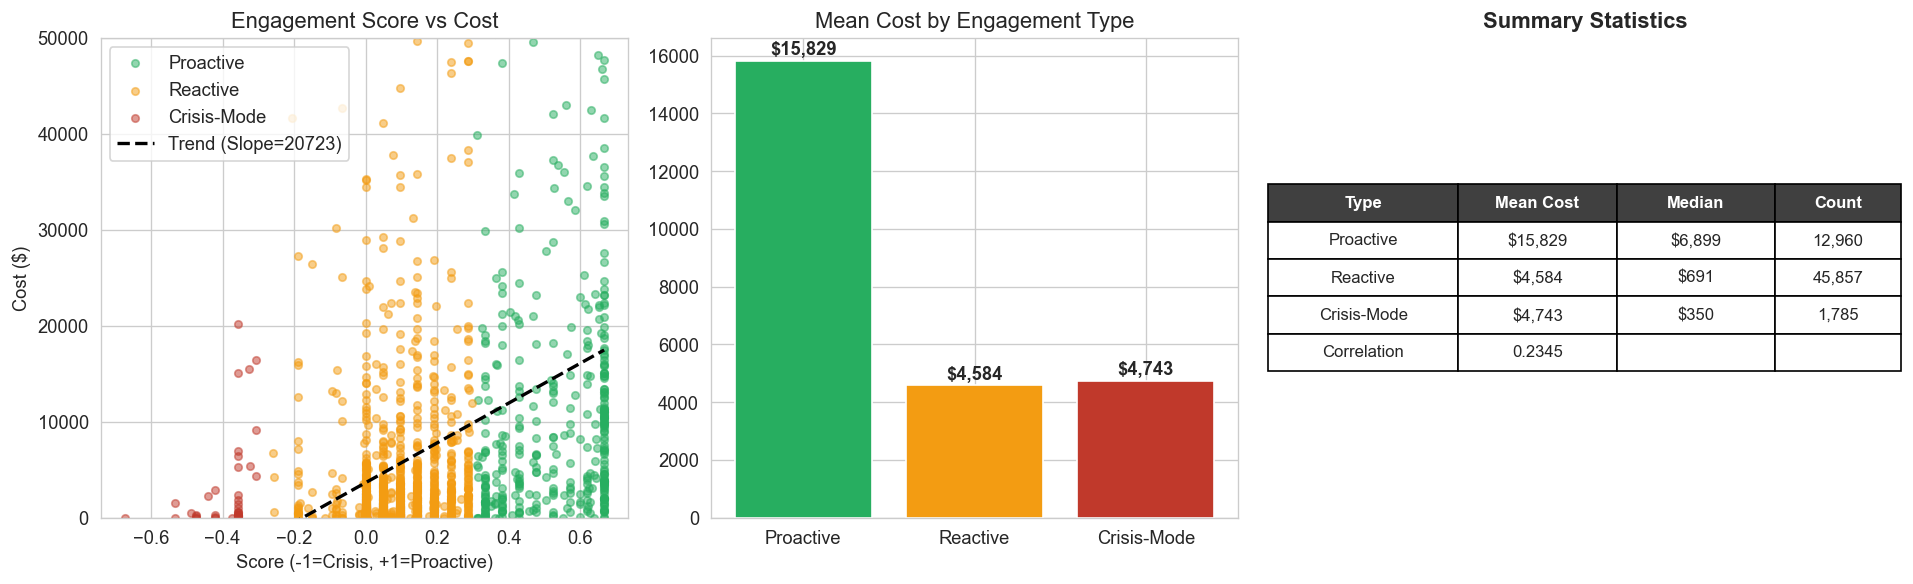

In [4]:
# VISUALIZATION: Stage 1.5B - Healthcare Engagement Score

if 'ENGAGEMENT_SCORE' in df.columns:
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # --- Panel 1: Scatter Plot ---
    ax1 = axes[0]
    sample = df.sample(min(2000, len(df)), random_state=42)
    
    # Color mapping
    colors = {'Proactive': '#27ae60', 'Reactive': '#f39c12', 'Crisis-Mode': '#c0392b'}
    for label, color in colors.items():
        subset = sample[sample['ENGAGEMENT_TYPE'] == label]
        ax1.scatter(subset['ENGAGEMENT_SCORE'], subset['COST_Y2_ADJ'], 
                   c=color, alpha=0.5, s=20, label=label)
                   
    # Trend line
    z = np.polyfit(sample['ENGAGEMENT_SCORE'], sample['COST_Y2_ADJ'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(sample['ENGAGEMENT_SCORE'].min(), sample['ENGAGEMENT_SCORE'].max(), 100)
    ax1.plot(x_range, p(x_range), 'k--', linewidth=2, label=f'Trend (Slope={z[0]:.0f})')
    
    ax1.set_title('Engagement Score vs Cost')
    ax1.set_xlabel('Score (-1=Crisis, +1=Proactive)')
    ax1.set_ylabel('Cost ($)')
    ax1.legend()
    ax1.set_ylim(0, 50000)
    
    # --- Panel 2: Mean Cost by Type ---
    ax2 = axes[1]
    stats = df.groupby('ENGAGEMENT_TYPE')['COST_Y2_ADJ'].agg(['mean', 'median', 'count']).reset_index()
    # Reorder
    order = ['Proactive', 'Reactive', 'Crisis-Mode']
    stats['ENGAGEMENT_TYPE'] = pd.Categorical(stats['ENGAGEMENT_TYPE'], categories=order, ordered=True)
    stats = stats.sort_values('ENGAGEMENT_TYPE')
    
    bars = ax2.bar(stats['ENGAGEMENT_TYPE'], stats['mean'], color=[colors[x] for x in stats['ENGAGEMENT_TYPE']])
    
    for bar, val in zip(bars, stats['mean']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
                 f'${val:,.0f}', ha='center', fontweight='bold')
                 
    ax2.set_title('Mean Cost by Engagement Type')
    
    # --- Panel 3: Real Table ---
    ax3 = axes[2]
    ax3.axis('off')
    
    corr = df['ENGAGEMENT_SCORE'].corr(df['COST_Y2_ADJ'])
    
    table_data = [['Type', 'Mean Cost', 'Median', 'Count']]
    for _, row in stats.iterrows():
        table_data.append([
            row['ENGAGEMENT_TYPE'], 
            f"${row['mean']:,.0f}", 
            f"${row['median']:,.0f}", 
            f"{row['count']:,}"
        ])
        
    table_data.append(['Correlation', f'{corr:.4f}', '', ''])
    
    table = ax3.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.3, 0.25, 0.25, 0.2])
    table.scale(1.2, 1.8)
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    
    for i in range(4):
        table[(0, i)].set_facecolor('#404040')
        table[(0, i)].set_text_props(color='white', fontweight='bold')

    ax3.set_title('Summary Statistics', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### Interpretation: Healthcare Engagement Score

**What the x-axis means**

- Higher `ENGAGEMENT_SCORE` = more office-centered, proactive care.
- Lower `ENGAGEMENT_SCORE` = more ER/IP-centered, crisis-driven care.

**Why this matters in healthcare**

Two patients can have the same total utilization count but very different care patterns. A patient with regular office follow-up and medication refills is clinically different from a patient whose contact is dominated by emergency or inpatient use. This engineered score captures that distinction in one variable.

**What to look for in the figure**

- If crisis-mode patients cluster at worse outcomes or higher instability, the score is separating care style, not just volume.
- If proactive patients still have non-trivial cost, that is not a contradiction. In chronic disease management, structured outpatient care can be expensive but still preferable to avoidable crisis escalation.

**How we use it**

`ENGAGEMENT_SCORE` is not a label. It is a compact proxy for care pattern that can help Stage 2 distinguish patients with similar baseline spend but different utilization behavior.


---
## Stage 1.5C: Escalation Magnitude Prediction

**What:** Predict expected cost-bin movement (`DELTA_BIN`) as a continuous feature.

**Method used in code:**
- `GradientBoostingRegressor`
- 5-fold **out-of-fold** predictions for leakage-safe feature generation

**Why this replaces binary jumper modeling:**
- A continuous movement target carries more information than a strict yes/no jumper label.
- OOF regression output is better suited as a Stage 2 feature than a sparse binary probability.

In [5]:
# STAGE 1.5C: Escalation Magnitude Prediction (Regression on DELTA_BIN)
#
# Previous approach: Binary classification (IS_JUMPER yes/no) → PROB_UNDIAGNOSED
# Problem: Negative correlation with cost, nearly all patients got near-zero probability
#
# New approach: Regression predicting DELTA_BIN (continuous cost bin change)
# This produces ESCALATION_MAGNITUDE — a score indicating how many bins
# the model expects a patient to jump, based on clinical signals.
#

print("STAGE 1.5C: Escalation Magnitude Prediction")

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict, KFold

if 'DELTA_BIN' in df.columns:
    print(f"\nTarget: DELTA_BIN (cost bin change Y2 - Y1)")
    print(f"  Mean: {df['DELTA_BIN'].mean():.3f}, Std: {df['DELTA_BIN'].std():.3f}")
    print(f"  Range: [{df['DELTA_BIN'].min()}, {df['DELTA_BIN'].max()}]")
    
    escalation_features = [
        'AGE_Y1', 'SEX',
        'CNT_ILL_DEFINED',
        'CNT_TOTAL_CONDITIONS',
        'UTIL_OB_Y1', 'UTIL_ER_Y1', 'UTIL_IP_Y1',
        'MNHLTH_RD1', 'RTHLTH_RD1',
        'CHRONIC_COUNT',
        'CNT_RX_Y1',
        'COST_Y1_ADJ',
        'ENGAGEMENT_SCORE'
    ]
    escalation_features = [f for f in escalation_features if f in df.columns]
    print(f"\nFeatures used ({len(escalation_features)}): {escalation_features}")
    
    X_esc = df[escalation_features].fillna(0)
    y_esc = df['DELTA_BIN']
    
    esc_model = GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    esc_preds = cross_val_predict(esc_model, X_esc, y_esc, cv=cv)
    df['ESCALATION_MAGNITUDE'] = esc_preds
    
    esc_model.fit(X_esc, y_esc)
    
    r_delta = np.corrcoef(esc_preds, y_esc)[0, 1]
    r_cost = np.corrcoef(df['ESCALATION_MAGNITUDE'], df['COST_Y2_ADJ'])[0, 1]
    
    print(f"\nLatent Factor Created: ESCALATION_MAGNITUDE")
    print(f"  Mean: {df['ESCALATION_MAGNITUDE'].mean():.3f}")
    print(f"  Std:  {df['ESCALATION_MAGNITUDE'].std():.3f}")
    print(f"  Correlation with actual DELTA_BIN: r = {r_delta:.3f}")
    print(f"  Correlation with COST_Y2_ADJ: r = {r_cost:.3f}")
    
    esc_importance = pd.DataFrame({
        'Feature': escalation_features,
        'Importance': esc_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop Features for Escalation Magnitude Prediction:")
    print(esc_importance.head(6).to_string(index=False))

else:
    print("WARNING: DELTA_BIN not available. Setting ESCALATION_MAGNITUDE = 0")
    df['ESCALATION_MAGNITUDE'] = 0.0

STAGE 1.5C: Escalation Magnitude Prediction

Target: DELTA_BIN (cost bin change Y2 - Y1)
  Mean: -0.015, Std: 1.139
  Range: [-4, 4]

Features used (13): ['AGE_Y1', 'SEX', 'CNT_ILL_DEFINED', 'CNT_TOTAL_CONDITIONS', 'UTIL_OB_Y1', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'CHRONIC_COUNT', 'CNT_RX_Y1', 'COST_Y1_ADJ', 'ENGAGEMENT_SCORE']



Latent Factor Created: ESCALATION_MAGNITUDE
  Mean: -0.015
  Std:  0.673
  Correlation with actual DELTA_BIN: r = 0.598
  Correlation with COST_Y2_ADJ: r = -0.095

Top Features for Escalation Magnitude Prediction:
             Feature  Importance
         COST_Y1_ADJ    0.513984
           CNT_RX_Y1    0.267414
CNT_TOTAL_CONDITIONS    0.053957
    ENGAGEMENT_SCORE    0.039498
          UTIL_IP_Y1    0.036469
              AGE_Y1    0.031481


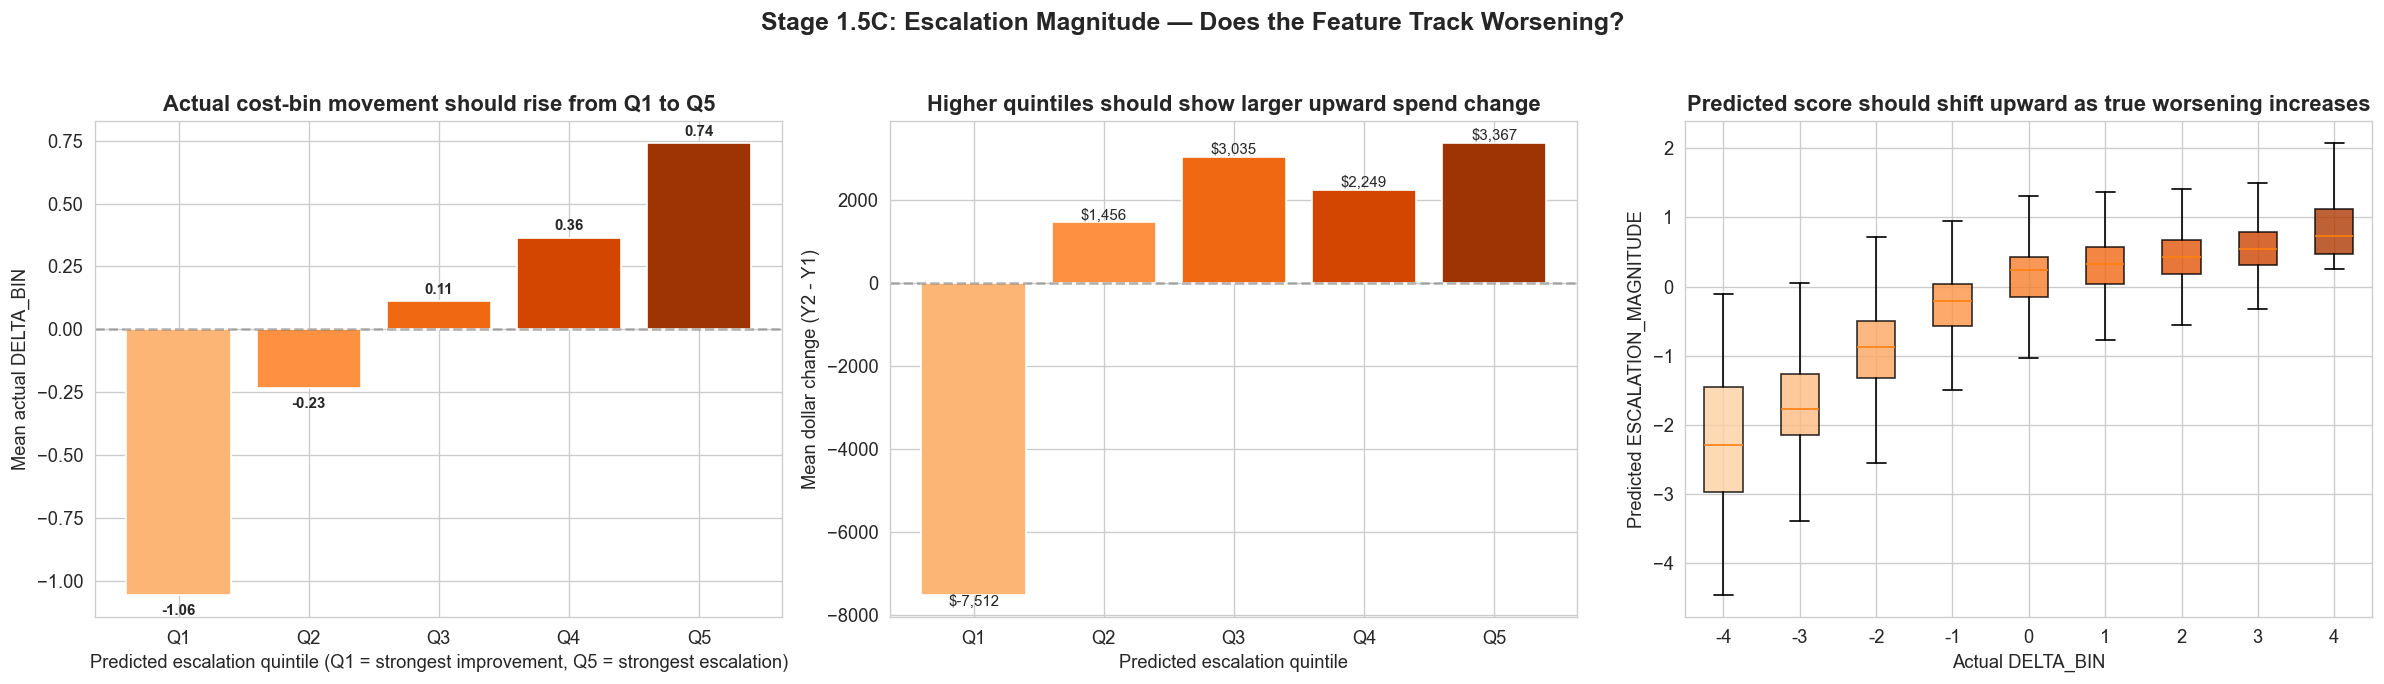

In [6]:

# VISUALIZATION: Stage 1.5C - Escalation Magnitude

if 'ESCALATION_MAGNITUDE' in df.columns:

    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
    fig.suptitle('Stage 1.5C: Escalation Magnitude — Does the Feature Track Worsening?', fontsize=15, fontweight='bold', y=1.03)

    viz = df[['ESCALATION_MAGNITUDE', 'DELTA_BIN', 'COST_Y1_ADJ', 'COST_Y2_ADJ']].copy()
    viz['DOLLAR_CHANGE'] = viz['COST_Y2_ADJ'] - viz['COST_Y1_ADJ']
    viz['_esc_quintile'] = pd.qcut(
        viz['ESCALATION_MAGNITUDE'].rank(method='first'),
        q=5,
        labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
    )

    stats = viz.groupby('_esc_quintile').agg(
        mean_delta=('DELTA_BIN', 'mean'),
        mean_dollar_change=('DOLLAR_CHANGE', 'mean'),
        mean_y1_cost=('COST_Y1_ADJ', 'mean'),
        mean_y2_cost=('COST_Y2_ADJ', 'mean'),
        count=('DELTA_BIN', 'count')
    ).reset_index()

    # Panel 1: actual delta by predicted quintile
    ax1 = axes[0]
    colors = plt.cm.Oranges(np.linspace(0.35, 0.9, 5))
    bars = ax1.bar(stats['_esc_quintile'], stats['mean_delta'], color=colors, edgecolor='white')
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.6)
    for bar, val in zip(bars, stats['mean_delta']):
        ax1.text(bar.get_x() + bar.get_width()/2, val + (0.03 if val >= 0 else -0.08), f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax1.set_xlabel('Predicted escalation quintile (Q1 = strongest improvement, Q5 = strongest escalation)')
    ax1.set_ylabel('Mean actual DELTA_BIN')
    ax1.set_title('Actual cost-bin movement should rise from Q1 to Q5', fontweight='bold')

    # Panel 2: dollar change rather than raw Y2 cost
    ax2 = axes[1]
    bars2 = ax2.bar(stats['_esc_quintile'], stats['mean_dollar_change'], color=colors, edgecolor='white')
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.6)
    for bar, val in zip(bars2, stats['mean_dollar_change']):
        ax2.text(bar.get_x() + bar.get_width()/2, val, f'${val:,.0f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
    ax2.set_xlabel('Predicted escalation quintile')
    ax2.set_ylabel('Mean dollar change (Y2 - Y1)')
    ax2.set_title('Higher quintiles should show larger upward spend change', fontweight='bold')

    # Panel 3: predicted magnitude by true delta bin
    ax3 = axes[2]
    delta_order = sorted(viz['DELTA_BIN'].dropna().unique())
    box_data = [viz.loc[viz['DELTA_BIN'] == d, 'ESCALATION_MAGNITUDE'].values for d in delta_order]
    bp = ax3.boxplot(box_data, labels=[str(d) for d in delta_order], patch_artist=True, showfliers=False)
    for patch, c in zip(bp['boxes'], plt.cm.Oranges(np.linspace(0.25, 0.85, len(delta_order)))):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax3.set_xlabel('Actual DELTA_BIN')
    ax3.set_ylabel('Predicted ESCALATION_MAGNITUDE')
    ax3.set_title('Predicted score should shift upward as true worsening increases', fontweight='bold')

    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'stage1_5c_escalation_magnitude.png', dpi=150, bbox_inches='tight')
    plt.show()


### Interpretation: Escalation Magnitude Feature

This figure is validating an engineered predictor, not a final model output.

**Axes and meaning**

- In panel 1, the x-axis is the predicted escalation quintile:
  - `Q1` = patients predicted to improve the most
  - `Q5` = patients predicted to worsen the most
- The y-axis is the **actual mean `DELTA_BIN`**. If the feature works, this should rise steadily from negative to positive.

- In panel 2, the y-axis is **mean dollar change (`Y2 - Y1`)**, not raw Year 2 cost.
  That is a more useful healthcare quantity here because the feature is supposed to capture **movement**, not simply absolute spend level.

- In panel 3, each box shows the distribution of predicted `ESCALATION_MAGNITUDE` for one true `DELTA_BIN` group.
  If the boxes shift upward as actual `DELTA_BIN` increases, the feature is ranking worsening correctly.

**Healthcare insight**

`ESCALATION_MAGNITUDE` is useful because it separates two very different situations that raw Y1 cost alone cannot:

- expensive patients who are likely to improve or stabilize,
- moderate-cost patients who are likely to jump upward next year.

That is exactly the kind of feature Stage 2 needs when expenditure is highly skewed and transition direction matters as much as baseline cost.


---
## Stage 1.5D: Removed Composite Escalation Score

A prior deterministic composite (`ESCALATION_SCORE`) was removed because:
1. Its components already existed directly in the base feature set.
2. It was highly redundant with Stage 1 latent outputs.
3. `ESCALATION_MAGNITUDE` (OOF model-based) captures nonlinear structure more effectively.

In [7]:
# STAGE 1.5D: REMOVED (Previously: Cost Escalation Pattern Score)
#
# ESCALATION_SCORE was a weighted average of normalize(CHRONIC_COUNT),
# normalize(CNT_ILL_DEFINED), normalize(UTIL_IP_Y1), normalize(POLYPHARMACY_FLAG).
#
# Why removed:
# 1. Correlation with LATENT_RISK_SCORE: r=0.73 (highly redundant with Stage 1)
# 2. All its components (CHRONIC_COUNT, UTIL_IP_Y1, etc.) are already in the
#    original feature set — wrapping them in a mean adds no new information.
# 3. The new ESCALATION_MAGNITUDE (1.5C) is model-based and more powerful.
#
print("STAGE 1.5D: REMOVED — ESCALATION_SCORE was redundant with Stage 1 features.")
print("  Replaced by ESCALATION_MAGNITUDE (regression-based, captures nonlinear interactions).")

STAGE 1.5D: REMOVED — ESCALATION_SCORE was redundant with Stage 1 features.
  Replaced by ESCALATION_MAGNITUDE (regression-based, captures nonlinear interactions).


---
## Stage 1.5E: Medication Adherence — Raw Feature Pass-Through

**Previous approach:** Trained a GradientBoosting classifier on Rx features + clinical features to predict P(Rising or Shock). The resulting HAZARD_DISCONTINUE had r=0.91 with LATENT_RISK_SCORE — nearly identical to Stage 1.

**New approach:** Skip the model entirely. The 4 raw Rx timeline features (RX_DENSITY, RX_GAP_RATIO, RX_TRAILING_GAP, RX_REGULARITY) extracted from MEPS prescribed medicines files are passed directly to Stage 2. These contain genuinely new information — temporal prescription patterns — that no other feature in the dataset captures.


In [8]:
# STAGE 1.5E: MEDICATION ADHERENCE RISK - Data Preparation
# 
# Goal: Extract medication timeline from Rx data to construct adherence features
# 
# Key Concepts:
# - TIME: Time from observation start to event (months)
# - EVENT: Whether event occurred (1=yes, 0=censored)
# - CENSORING: Observation ended but event didn't occur; we don't know if it will happen later
#

print("="*60)
print("STAGE 1.5E: Survival Analysis - Treatment Discontinuation")
print("="*60)

# Panel mapping for medication files
PANEL_MEDS_MAP = {
    18: {'meds': 'h160a', 'year1': 2013},
    19: {'meds': 'h168a', 'year1': 2014},
    20: {'meds': 'h178a', 'year1': 2015},
    21: {'meds': 'h188a', 'year1': 2016},
    22: {'meds': 'h206a', 'year1': 2017},
    23: {'meds': 'h206a', 'year1': 2018},
}

# Data directories
MEDS_DIR = Path('../archive_v1/data/processed')
MEDS_DIR_V2 = Path('../data/processed_v2')

def extract_medication_timeline(panel_id, panel_info):
    """
    Extract medication timeline from prescription files for each patient
    
    Returns: DataFrame with columns:
    - DUPERSID: Patient ID
    - FIRST_RX_MONTH: First prescription month (1-24, 1=Year1 Jan, 13=Year2 Jan)
    - LAST_RX_MONTH: Last prescription month
    - RX_MONTHS: List of months with prescriptions
    - TOTAL_RX_COUNT: Total prescription count
    - GAP_MAX: Maximum consecutive gap without prescriptions (months)
    """
    meds_file = MEDS_DIR / f"{panel_info['meds']}.parquet"
    if not meds_file.exists():
        meds_file = MEDS_DIR_V2 / f"{panel_info['meds']}.parquet"
    
    if not meds_file.exists():
        print(f"  Panel {panel_id}: Medication file not found, skipping")
        return None
    
    try:
        meds = pd.read_parquet(meds_file)
    except Exception as e:
        print(f"  Panel {panel_id}: Error reading file - {e}")
        return None
    
    year1 = panel_info['year1']
    year2 = year1 + 1
    
    # Look for time columns - MEPS prescription files typically have RXBEGMM (month) and RXBEGYR (year)
    # Or date-formatted variables
    time_cols_mm = [c for c in meds.columns if 'RXBEG' in c.upper() and 'MM' in c.upper()]
    time_cols_yr = [c for c in meds.columns if 'RXBEG' in c.upper() and 'YR' in c.upper()]
    
    if not time_cols_mm or not time_cols_yr:
        # Try other naming patterns
        time_cols_mm = [c for c in meds.columns if 'PURCHMM' in c.upper() or 'FILLMM' in c.upper()]
        time_cols_yr = [c for c in meds.columns if 'PURCHYR' in c.upper() or 'FILLYR' in c.upper()]
    
    if not time_cols_mm:
        print(f"  Panel {panel_id}: No time columns found. Available: {list(meds.columns)[:10]}...")
        return None
    
    mm_col = time_cols_mm[0]
    yr_col = time_cols_yr[0] if time_cols_yr else None
    
    print(f"  Panel {panel_id}: Using time columns {mm_col}, {yr_col}")
    
    # Calculate relative month (1 = Year1 January, 13 = Year2 January, 24 = Year2 December)
    def calc_relative_month(row):
        month = row[mm_col]
        if pd.isna(month) or month < 1 or month > 12:
            return None
        
        if yr_col and yr_col in row.index:
            year = row[yr_col]
            if year == year1:
                return int(month)  # 1-12
            elif year == year2:
                return int(month) + 12  # 13-24
            else:
                return None
        else:
            # If no year info, assume sequential order
            return int(month)
    
    meds['REL_MONTH'] = meds.apply(calc_relative_month, axis=1)
    meds = meds.dropna(subset=['REL_MONTH', 'DUPERSID'])
    
    if len(meds) == 0:
        print(f"  Panel {panel_id}: No valid records after time processing")
        return None
    
    # Aggregate by patient
    patient_timeline = meds.groupby('DUPERSID').agg({
        'REL_MONTH': ['min', 'max', 'count', lambda x: sorted(x.unique().tolist())]
    }).reset_index()
    
    patient_timeline.columns = ['DUPERSID', 'FIRST_RX_MONTH', 'LAST_RX_MONTH', 
                                 'TOTAL_RX_COUNT', 'RX_MONTHS']
    
    # Calculate maximum gap
    def calc_max_gap(months_list):
        if len(months_list) < 2:
            return 0
        months_sorted = sorted(months_list)
        max_gap = 0
        for i in range(1, len(months_sorted)):
            gap = months_sorted[i] - months_sorted[i-1] - 1
            max_gap = max(max_gap, gap)
        return max_gap
    
    patient_timeline['GAP_MAX'] = patient_timeline['RX_MONTHS'].apply(calc_max_gap)
    patient_timeline['PANEL'] = panel_id
    
    print(f"  Panel {panel_id}: Extracted timeline for {len(patient_timeline)} patients")
    return patient_timeline

# Extract medication timeline for all panels
print("\n--- Extracting Medication Timelines ---")
all_timelines = []

for panel_id, panel_info in PANEL_MEDS_MAP.items():
    timeline = extract_medication_timeline(panel_id, panel_info)
    if timeline is not None:
        all_timelines.append(timeline)

if all_timelines:
    medication_timeline_df = pd.concat(all_timelines, ignore_index=True)
    print(f"\n✓ Total patients with medication timeline: {len(medication_timeline_df):,}")
else:
    print("\n⚠ No medication timeline data extracted. Creating dummy variables.")
    medication_timeline_df = None

STAGE 1.5E: Survival Analysis - Treatment Discontinuation

--- Extracting Medication Timelines ---


  Panel 18: Using time columns RXBEGMM, RXBEGYRX


  Panel 18: Extracted timeline for 14063 patients
  Panel 19: Using time columns RXBEGMM, RXBEGYRX


  Panel 19: Extracted timeline for 13390 patients
  Panel 20: Using time columns RXBEGMM, RXBEGYRX


  Panel 20: Extracted timeline for 13674 patients
  Panel 21: Using time columns RXBEGMM, RXBEGYRX


  Panel 21: Extracted timeline for 12955 patients
  Panel 22: Using time columns RXBEGMM, RXBEGYRX


  Panel 22: Extracted timeline for 13998 patients
  Panel 23: Using time columns RXBEGMM, RXBEGYRX


  Panel 23: Extracted timeline for 12268 patients

✓ Total patients with medication timeline: 80,348


In [9]:
# STAGE 1.5E: Construct Medication Adherence Risk Score
#
# Problem with original approach: MEPS medication data covers Year 1 only for most
# patients, so with observation_end=24 months, 100% of patients "discontinue"
# (no one has fills in months 13-24 if only Y1 Rx data exists).
#
# Revised approach: Construct a MEDICATION ADHERENCE RISK score from Year 1 Rx
# timeline features. Patients with poor adherence (large gaps, early drop-off,
# low fill density) are at higher risk of adverse outcomes in Year 2.
#
# This is clinically grounded: medication non-adherence is one of the strongest
# predictors of hospitalization and cost escalation (Sokol et al., 2005; 
# Roebuck et al., 2011).

print("\n--- Constructing Medication Adherence Risk Score ---")

def construct_adherence_variables(timeline_df):
    """
    Construct medication adherence risk variables from Year 1 Rx timeline.
    
    Output variables:
    - RX_DENSITY: Proportion of Y1 months with at least one fill (0-1)
    - RX_GAP_RATIO: Max gap / observation months (0-1, higher = worse adherence)
    - RX_TRAILING_GAP: Months from last fill to end of Y1 (higher = dropped off)
    - RX_REGULARITY: Std dev of inter-fill gaps (higher = more erratic)
    """
    if timeline_df is None or len(timeline_df) == 0:
        return None
    
    survival_data = timeline_df.copy()
    
    def calc_adherence(row):
        rx_months = row['RX_MONTHS']
        first_rx = row['FIRST_RX_MONTH']
        last_rx = row['LAST_RX_MONTH']
        max_gap = row['GAP_MAX']
        
        if not rx_months or len(rx_months) == 0:
            return 0.0, 1.0, 12.0, 0.0
        
        # Only consider Year 1 months (1-12)
        y1_months = sorted([m for m in rx_months if 1 <= m <= 12])
        
        if len(y1_months) == 0:
            return 0.0, 1.0, 12.0, 0.0
        
        unique_months = len(set(y1_months))
        observation_span = 12  # Year 1 = 12 months
        
        # RX_DENSITY: fraction of Y1 months with at least one fill
        density = unique_months / observation_span
        
        # RX_GAP_RATIO: max gap relative to observation
        y1_max_gap = 0
        for i in range(1, len(y1_months)):
            gap = y1_months[i] - y1_months[i-1] - 1
            y1_max_gap = max(y1_max_gap, gap)
        gap_ratio = y1_max_gap / observation_span
        
        # RX_TRAILING_GAP: months from last Y1 fill to end of Y1
        trailing = 12 - max(y1_months)
        
        # RX_REGULARITY: std of inter-fill intervals (0 if only 1 month)
        if len(y1_months) > 1:
            intervals = [y1_months[i] - y1_months[i-1] for i in range(1, len(y1_months))]
            regularity = float(np.std(intervals))
        else:
            regularity = 0.0
        
        return density, gap_ratio, float(trailing), regularity
    
    results = survival_data.apply(calc_adherence, axis=1, result_type='expand')
    survival_data['RX_DENSITY'] = results[0]
    survival_data['RX_GAP_RATIO'] = results[1]
    survival_data['RX_TRAILING_GAP'] = results[2]
    survival_data['RX_REGULARITY'] = results[3]
    
    return survival_data

if medication_timeline_df is not None:
    survival_df = construct_adherence_variables(medication_timeline_df)
    
    if survival_df is not None:
        print(f"\n=== Medication Adherence Summary ===")
        print(f"Total patients with Rx data: {len(survival_df):,}")
        
        for col in ['RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']:
            s = survival_df[col]
            print(f"\n  {col}:")
            print(f"    Mean: {s.mean():.3f}, Std: {s.std():.3f}, Range: [{s.min():.2f}, {s.max():.2f}]")
else:
    survival_df = None
    print("Warning: Survival data not available. Skipping.")


--- Constructing Medication Adherence Risk Score ---



=== Medication Adherence Summary ===
Total patients with Rx data: 80,348

  RX_DENSITY:
    Mean: 0.119, Std: 0.087, Range: [0.00, 0.83]

  RX_GAP_RATIO:
    Mean: 0.206, Std: 0.333, Range: [0.00, 1.00]

  RX_TRAILING_GAP:
    Mean: 5.664, Std: 4.036, Range: [0.00, 12.00]

  RX_REGULARITY:
    Mean: 0.166, Std: 0.559, Range: [0.00, 4.50]


In [10]:
# STAGE 1.5E: Medication Adherence - Raw Feature Pass-Through
#
# Previous approach wrapped Rx timeline variables into a classifier output
# that was highly redundant with Stage 1 latent risk.
#
# Current approach passes raw timeline variables directly and tracks whether
# each row required default imputation after merge.

print()
print("Stage 1.5E: Merging Raw Rx Timeline Features (No Model Wrapper)")

RX_FEATS = ['RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']

if survival_df is not None and len(survival_df) > 100:

    survival_df['DUPERSID'] = survival_df['DUPERSID'].astype(str)
    df['DUPERSID'] = df['DUPERSID'].astype(str)

    merge_cols = ['DUPERSID', 'PANEL'] + RX_FEATS
    df_surv = df.merge(
        survival_df[merge_cols],
        on=['DUPERSID', 'PANEL'],
        how='left',
    )

    matched = df_surv['RX_DENSITY'].notna()
    match_rate = matched.mean() * 100
    print(f"  Match rate: {match_rate:.1f}%")

    panel_match = df_surv.groupby('PANEL')['RX_DENSITY'].apply(lambda s: s.notna().mean()).round(3)
    print("  Match rate by panel:")
    print(panel_match.to_string())

    # Track rows without timeline data
    df_surv['RX_TIMELINE_IMPUTED'] = (~matched).astype(int)

    # Fill unmatched rows with conservative defaults
    fill_defaults = {
        'RX_DENSITY': 0.0,
        'RX_GAP_RATIO': 1.0,
        'RX_TRAILING_GAP': 12.0,
        'RX_REGULARITY': 0.0,
    }
    for col, default in fill_defaults.items():
        df_surv[col] = df_surv[col].fillna(default)

    for col in RX_FEATS + ['RX_TIMELINE_IMPUTED']:
        df[col] = df_surv[col].values

    if match_rate < 50:
        print("  Warning: Rx timeline merge coverage is low; imputation flag kept for Stage 2.")

    print()
    print("  Raw Rx features merged (no model wrapper):")
    for col in RX_FEATS:
        print(f"    {col}: mean={df[col].mean():.3f}, std={df[col].std():.3f}")
    print(f"    RX_TIMELINE_IMPUTED: mean={df['RX_TIMELINE_IMPUTED'].mean():.3f}")

    print()
    print("  Correlation with COST_Y2_ADJ:")
    for col in RX_FEATS + ['RX_TIMELINE_IMPUTED']:
        r = df[col].corr(df['COST_Y2_ADJ'])
        print(f"    {col}: r = {r:.3f}")

else:
    print("  Warning: No medication timeline data. Setting Rx features to defaults + imputed flag.")
    df['RX_DENSITY'] = 0.0
    df['RX_GAP_RATIO'] = 1.0
    df['RX_TRAILING_GAP'] = 12.0
    df['RX_REGULARITY'] = 0.0
    df['RX_TIMELINE_IMPUTED'] = 1

print()
print("  Done. Raw Rx features available for Stage 2.")


Stage 1.5E: Merging Raw Rx Timeline Features (No Model Wrapper)
  Match rate: 43.8%
  Match rate by panel:
PANEL
18    0.420
19    0.427
20    0.430
21    0.415
22    0.500
23    0.439

  Raw Rx features merged (no model wrapper):
    RX_DENSITY: mean=0.054, std=0.085
    RX_GAP_RATIO: mean=0.648, std=0.451
    RX_TRAILING_GAP: mean=9.167, std=4.135
    RX_REGULARITY: mean=0.078, std=0.392
    RX_TIMELINE_IMPUTED: mean=0.562

  Correlation with COST_Y2_ADJ:
    RX_DENSITY: r = 0.199
    RX_GAP_RATIO: r = -0.142
    RX_TRAILING_GAP: r = -0.166
    RX_REGULARITY: r = 0.115
    RX_TIMELINE_IMPUTED: r = -0.183

  Done. Raw Rx features available for Stage 2.



--- Rx Timeline Feature Visualizations ---


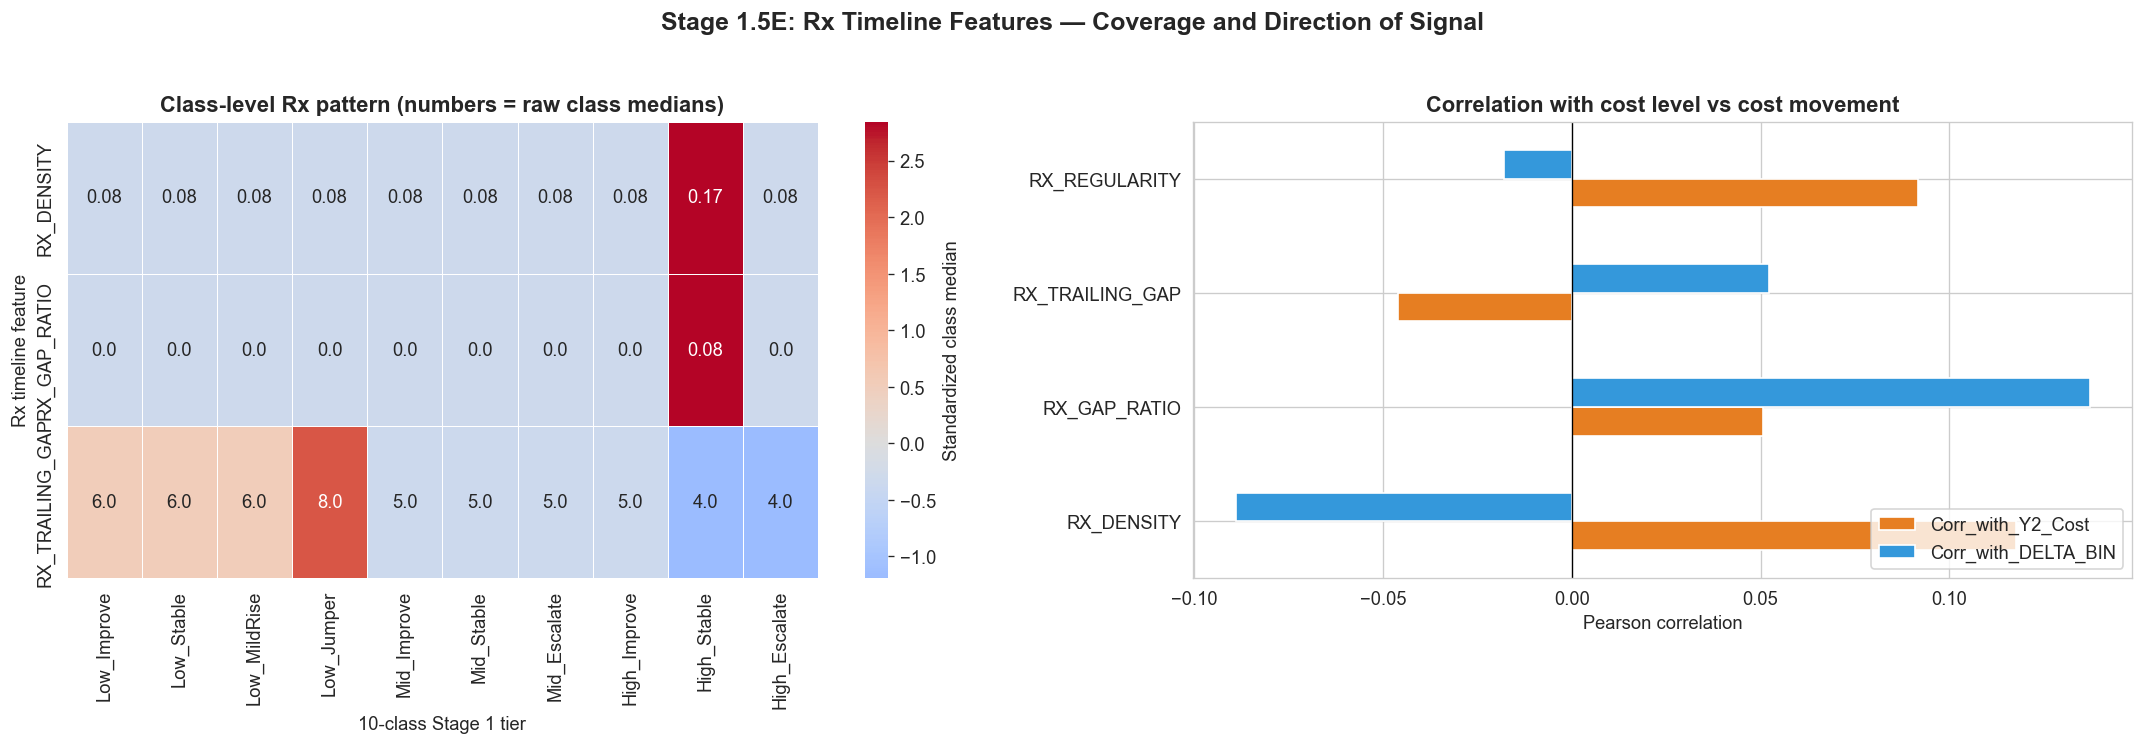

In [11]:

# STAGE 1.5E: Raw Rx Feature Visualization (readable summary)

print()
print("--- Rx Timeline Feature Visualizations ---")

RX_VIZ_FEATS = ['RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']

if all(f in df.columns for f in RX_VIZ_FEATS) and df['RX_DENSITY'].notna().sum() > 100:

    hv = df[df['RX_TIMELINE_IMPUTED'] == 0].copy() if 'RX_TIMELINE_IMPUTED' in df.columns else df.copy()
    tier_labels = {t: CLASS_NAMES.get(t, str(t)) for t in sorted(hv['RISK_TIER'].unique())}

    corr_feats = []
    heatmap_feats = []
    for feat in RX_VIZ_FEATS:
        if hv[feat].nunique(dropna=True) > 1 and hv[feat].std() > 1e-8:
            corr_feats.append(feat)
            class_medians = hv.groupby('RISK_TIER')[feat].median().round(3)
            if class_medians.nunique() > 1:
                heatmap_feats.append(feat)

    if len(corr_feats) == 0:
        print("All Rx timeline features are constant after merge; skipping plot.")
    else:
        corr_rows = []
        for feat in corr_feats:
            corr_rows.append({
                'Feature': feat,
                'Corr_with_Y2_Cost': hv[feat].corr(hv['COST_Y2_ADJ']),
                'Corr_with_DELTA_BIN': hv[feat].corr(hv['DELTA_BIN']) if 'DELTA_BIN' in hv.columns else np.nan,
            })
        corr_df = pd.DataFrame(corr_rows).set_index('Feature')

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle('Stage 1.5E: Rx Timeline Features — Coverage and Direction of Signal', fontsize=15, fontweight='bold', y=1.03)

        if heatmap_feats:
            median_table = (
                hv.groupby('RISK_TIER')[heatmap_feats]
                .median()
                .rename(index=tier_labels)
            )

            # Standardize medians for readability across different units
            heatmap_input = median_table.copy()
            for col in heatmap_input.columns:
                col_std = heatmap_input[col].std()
                if col_std > 1e-12:
                    heatmap_input[col] = (heatmap_input[col] - heatmap_input[col].mean()) / col_std
                else:
                    heatmap_input[col] = 0.0

            sns.heatmap(
                heatmap_input.T,
                cmap='coolwarm',
                center=0,
                annot=median_table.T.round(2),
                fmt='',
                linewidths=0.5,
                ax=axes[0],
                cbar_kws={'label': 'Standardized class median'}
            )
            axes[0].set_title('Class-level Rx pattern (numbers = raw class medians)', fontweight='bold')
            axes[0].set_xlabel('10-class Stage 1 tier')
            axes[0].set_ylabel('Rx timeline feature')
        else:
            axes[0].axis('off')
            axes[0].text(
                0.5, 0.5,
                'Class medians were flat after merge;\nshowing only the correlation summary on the right.',
                ha='center', va='center', fontsize=11
            )

        corr_plot = corr_df[['Corr_with_Y2_Cost', 'Corr_with_DELTA_BIN']]
        corr_plot.plot(kind='barh', ax=axes[1], color=['#e67e22', '#3498db'], edgecolor='white')
        axes[1].axvline(0, color='black', lw=0.8)
        axes[1].set_title('Correlation with cost level vs cost movement', fontweight='bold')
        axes[1].set_xlabel('Pearson correlation')
        axes[1].set_ylabel('')
        axes[1].legend(loc='lower right')

        plt.tight_layout()
        plt.savefig(REPORT_DIR / 'figures' / 'stage1_5e_rx_features.png', dpi=150, bbox_inches='tight')
        plt.show()

        dropped = [f for f in RX_VIZ_FEATS if f not in corr_feats]
        if dropped:
            print(f"Dropped from plot because they were constant or visually uninformative: {dropped}")

else:
    print("Rx timeline features not available for visualization.")


### Interpretation: Raw Rx Timeline Features (Stage 1.5E)

The earlier boxplots were difficult to read because these variables are on very different scales and some had almost no variation. This revised figure is answering two simpler questions.

**Panel 1: Which risk tiers have different refill patterns?**

- Each cell is one Stage 1 risk tier by one Rx timeline feature.
- The color shows the median relative to other tiers.
- The number inside each cell is the **raw median**, so the plot stays interpretable in the original units.
- If a feature has almost no between-class median variation, we leave it out of the heatmap instead of showing a meaningless row of zeros.

**Panel 2: Are these features related to cost level or cost movement?**

- `Corr_with_Y2_Cost` asks whether the feature is associated with higher or lower Year 2 spending.
- `Corr_with_DELTA_BIN` asks whether it is associated with upward or downward movement in cost bins.

**Healthcare interpretation**

- `RX_DENSITY` and `RX_REGULARITY` are closer to medication continuity.
- `RX_GAP_RATIO` and `RX_TRAILING_GAP` are closer to refill disruption or discontinuation.
- A feature is most useful when it adds information not already contained in baseline cost and when its sign makes clinical sense.

If a feature is constant after merge or too sparse to interpret reliably, we drop it from the visual rather than forcing an empty plot into the notebook.


---
## Stage 1.5 Summary: All Latent Factors

The correlation matrix below shows how each latent factor relates to the others and to Y2 cost. Key things to look for:
- **Correlation with COST_Y2_ADJ:** Factors with |r| > 0.1 add signal
- **Inter-factor correlation:** Low correlation between Stage 1.5 factors means they capture different aspects of risk (desirable); high correlation means redundancy
- **Correlation with LATENT_RISK_SCORE:** Factors that are independent of the Stage 1 score add the most marginal value to Stage 2


In [12]:
# STAGE 1.5 SUMMARY

print("STAGE 1.5 SUMMARY: Intermediate Latent Factors")


# All Stage 1.5 enrichment features
stage1_5_factors = [
    'ENGAGEMENT_SCORE',       # Stage 1.5B: Healthcare Engagement (direct calc)
    'ESCALATION_MAGNITUDE',   # Stage 1.5C: Predicted cost bin change (regression)
]

# Raw Rx features passed through from 1.5E (not model-wrapped)
rx_pass_through = ['RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']

all_enrichment_features = stage1_5_factors + rx_pass_through

# Summary statistics
summary_data = []
for factor in all_enrichment_features:
    if factor in df.columns:
        summary_data.append({
            'Feature': factor,
            'Mean': df[factor].mean(),
            'Std': df[factor].std(),
            'Min': df[factor].min(),
            'Max': df[factor].max()
        })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Correlation with target and DELTA_BIN
print("\n\nCorrelation with COST_Y2_ADJ and DELTA_BIN:")
for factor in all_enrichment_features:
    if factor in df.columns:
        r_cost = df[factor].corr(df['COST_Y2_ADJ'])
        r_delta = df[factor].corr(df['DELTA_BIN']) if 'DELTA_BIN' in df.columns else np.nan
        r_latent = df[factor].corr(df['LATENT_RISK_SCORE']) if 'LATENT_RISK_SCORE' in df.columns else np.nan
        print(f"  {factor:25s}: r_cost={r_cost:.3f}, r_delta={r_delta:.3f}, r_latent={r_latent:.3f}")

STAGE 1.5 SUMMARY: Intermediate Latent Factors

             Feature      Mean      Std       Min       Max
    ENGAGEMENT_SCORE  0.150575 0.236308 -1.000000  0.666667
ESCALATION_MAGNITUDE -0.015314 0.673303 -4.464572  3.338868
          RX_DENSITY  0.054352 0.085387  0.000000  0.833333
        RX_GAP_RATIO  0.647756 0.451065  0.000000  1.000000
     RX_TRAILING_GAP  9.166859 4.134775  0.000000 12.000000
       RX_REGULARITY  0.078343 0.391858  0.000000  4.500000


Correlation with COST_Y2_ADJ and DELTA_BIN:
  ENGAGEMENT_SCORE         : r_cost=0.235, r_delta=-0.058, r_latent=-0.226
  ESCALATION_MAGNITUDE     : r_cost=-0.095, r_delta=0.598, r_latent=0.897
  RX_DENSITY               : r_cost=0.199, r_delta=-0.109, r_latent=-0.229
  RX_GAP_RATIO             : r_cost=-0.142, r_delta=0.125, r_latent=0.251
  RX_TRAILING_GAP          : r_cost=-0.166, r_delta=0.094, r_latent=0.231
  RX_REGULARITY            : r_cost=0.115, r_delta=-0.033, r_latent=-0.080


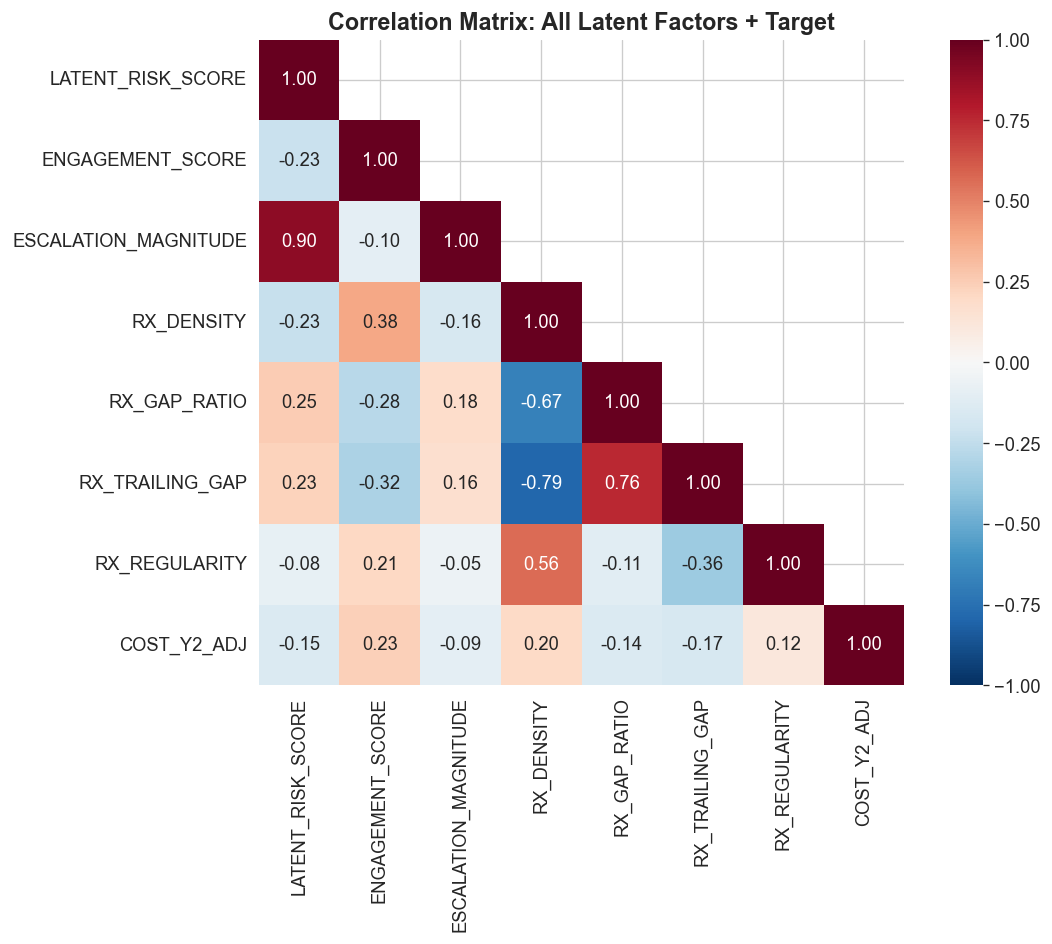

In [13]:
# Correlation heatmap of all latent factors
latent_cols = ['LATENT_RISK_SCORE'] + all_enrichment_features
latent_cols = [c for c in latent_cols if c in df.columns]

if len(latent_cols) > 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    corr_matrix = df[latent_cols + ['COST_Y2_ADJ']].corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, ax=ax)
    
    ax.set_title('Correlation Matrix: All Latent Factors + Target', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'latent_factors_correlation.png', dpi=150)
    plt.show()
else:
    print("Insufficient latent factors for correlation heatmap")

### Latent Factors Correlation Matrix

This heatmap is a **screening tool**, not a proof by itself.

Use it to answer:

- Which engineered variables are actually related to Year 2 cost?
- Which ones are mostly duplicating `LATENT_RISK_SCORE`?
- Which ones seem to capture a different aspect of risk, such as care pattern, transition direction, or medication continuity?

A good Stage 1.5 feature does not have to dominate cost prediction on its own. It only needs to add a piece of information that is plausibly useful **after baseline cost is already known**.


---
# STAGE 2: Expenditure Prediction (Transition-Based)

**Goal:** Predict individual Year 2 cost from Year 1 features + Stage 1/1.5 enrichment.

**Design choices in this version:**
1. 10-class transition system (same `RISK_TIER` definition as Stage 1)
2. Leakage-safe inference routing by `STAGE1_PRED_CLASS` (not true tier labels)
3. Class-specific models with class-dependent regularization
4. Global fallback model for missing/unstable class models
5. Duan's smearing correction applied consistently for dollar-scale predictions

**Feature blocks:**
- Original Year 1 features
- Engineered interactions
- Stage 1 outputs (`PROB_*`, `LATENT_RISK_SCORE`)
- Stage 1.5 enrichment (`ENGAGEMENT_SCORE`, `ESCALATION_MAGNITUDE`, `RX_*`, optional imputation flag)

In [14]:
# STAGE 2: Feature Preparation (2D Classification, 10 Classes)
print('STAGE 2: 2D Class-Specific Cost Prediction (Hard vs Soft Routing)')

ORIGINAL_FEATS = [
    'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1',
    'MNHLTH_RD1', 'RTHLTH_RD1',
    'CHRONIC_COUNT', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG',
    'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1',
    'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1',
    'RATIO_ER_OFFICE', 'COST_Y1_ADJ'
]

STAGE1_5_FEATS = [
    'ENGAGEMENT_SCORE',
    'ESCALATION_MAGNITUDE',
    'RX_DENSITY',
    'RX_GAP_RATIO',
    'RX_TRAILING_GAP',
    'RX_REGULARITY',
    'RX_TIMELINE_IMPUTED',
]

# Engineered interaction features
df['LOG_COST_Y1'] = np.log1p(df['COST_Y1_ADJ'].clip(lower=0))
df['COST_X_CHRONIC'] = df['COST_Y1_ADJ'] * df['CHRONIC_COUNT']
df['AGE_X_CHRONIC'] = df['AGE_Y1'] * df['CHRONIC_COUNT']
df['UTIL_TOTAL_Y1'] = df['UTIL_ER_Y1'] + df['UTIL_IP_Y1'] + df['UTIL_OB_Y1'] + df['UTIL_RX_Y1']
df['IP_FLAG'] = (df['UTIL_IP_Y1'] > 0).astype(int)
df['HIGH_COST_FLAG'] = (df['COST_Y1_ADJ'] > df['COST_Y1_ADJ'].quantile(0.75)).astype(int)

INTERACTION_FEATS = [
    'LOG_COST_Y1', 'COST_X_CHRONIC', 'AGE_X_CHRONIC',
    'UTIL_TOTAL_Y1', 'IP_FLAG', 'HIGH_COST_FLAG'
]

# Validate Stage 1 probability columns
class_order = np.array(sorted(CLASS_NAMES.keys()))
prob_cols_primary = [f"PROB_{CLASS_NAMES[c].upper()}" for c in class_order]
prob_cols_alias = [f"P_{CLASS_NAMES[c].upper()}" for c in class_order]

if all(c in df.columns for c in prob_cols_primary):
    stage1_prob_cols = prob_cols_primary
elif all(c in df.columns for c in prob_cols_alias):
    stage1_prob_cols = prob_cols_alias
else:
    missing = [c for c in prob_cols_primary if c not in df.columns]
    raise ValueError(
        "Missing Stage 1 probability columns required for routing: " + ", ".join(missing)
    )

prob_matrix = df[stage1_prob_cols].to_numpy()

# Standardize Stage 1 decision fields for Stage 2
if 'pred_class_hard' not in df.columns:
    df['pred_class_hard'] = class_order[prob_matrix.argmax(axis=1)]
if 'pred_class_policy' not in df.columns:
    df['pred_class_policy'] = df['pred_class_hard']
if 'review_flag' not in df.columns:
    df['review_flag'] = 0
if 'uncertainty_score' not in df.columns:
    if 'PRED_ENTROPY' in df.columns:
        df['uncertainty_score'] = df['PRED_ENTROPY'] / np.log(len(class_order))
    else:
        df['uncertainty_score'] = 0.0

# Keep compatibility label
if 'STAGE1_PRED_CLASS' not in df.columns:
    df['STAGE1_PRED_CLASS'] = df['pred_class_hard']

original_avail = [f for f in ORIGINAL_FEATS if f in df.columns]
stage1_5_avail = [f for f in STAGE1_5_FEATS if f in df.columns]
interact_avail = [f for f in INTERACTION_FEATS if f in df.columns]

# Tier-specific model features
TIER_FEATS = original_avail + interact_avail + ['LATENT_RISK_SCORE'] + stage1_5_avail + ['uncertainty_score']
TIER_FEATS = [f for f in TIER_FEATS if f in df.columns]

# Global model features include per-class probabilities and decision uncertainty
ALL_FEATS = original_avail + interact_avail + stage1_prob_cols + ['LATENT_RISK_SCORE'] + stage1_5_avail + ['uncertainty_score']
ALL_FEATS = [f for f in ALL_FEATS if f in df.columns]

print(f'Tier-specific features ({len(TIER_FEATS)}): {TIER_FEATS}')
print(f'Global features ({len(ALL_FEATS)})')
print(f'Stage 1.5 features: {stage1_5_avail}')

agreement_hard = (df['pred_class_hard'] == df['RISK_TIER']).mean()
policy_coverage = (df['pred_class_policy'] >= 0).mean()
print(f'Stage 1 hard-class agreement vs true tier: {agreement_hard:.3f}')
print(f'Stage 1 policy coverage (non-REVIEW): {policy_coverage:.3f}')

STAGE 2: 2D Class-Specific Cost Prediction (Hard vs Soft Routing)
Tier-specific features (36): ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'CHRONIC_COUNT', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'LOG_COST_Y1', 'COST_X_CHRONIC', 'AGE_X_CHRONIC', 'UTIL_TOTAL_Y1', 'IP_FLAG', 'HIGH_COST_FLAG', 'LATENT_RISK_SCORE', 'ENGAGEMENT_SCORE', 'ESCALATION_MAGNITUDE', 'RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY', 'RX_TIMELINE_IMPUTED', 'uncertainty_score']
Global features (46)
Stage 1.5 features: ['ENGAGEMENT_SCORE', 'ESCALATION_MAGNITUDE', 'RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY', 'RX_TIMELINE_IMPUTED']
Stage 1 hard-class agreement vs true tier: 0.505
Stage 1 policy coverage (non-REVIEW): 1.000


In [15]:
# Data Split: Stratified by Panel (7:2:1)
print("\n--- Data Split (Stratified by Panel: 70/20/10) ---")

def stratified_panel_split(df, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, random_state=42):
    """Split data stratified by PANEL to maintain temporal distribution."""
    train_list, val_list, test_list = [], [], []
    
    for panel in sorted(df['PANEL'].unique()):
        panel_data = df[df['PANEL'] == panel].copy()
        n = len(panel_data)
        
        # Shuffle
        panel_data = panel_data.sample(frac=1, random_state=random_state)
        
        # Split indices
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        
        train_list.append(panel_data.iloc[:n_train])
        val_list.append(panel_data.iloc[n_train:n_train+n_val])
        test_list.append(panel_data.iloc[n_train+n_val:])
        
        print(f"  Panel {panel}: Train={n_train}, Val={n_val}, Test={n-n_train-n_val}")
    
    return pd.concat(train_list), pd.concat(val_list), pd.concat(test_list)

# Perform split
df_train, df_val, df_test = stratified_panel_split(df)

print(f"\nFinal Split:")
print(f"  Train: {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val:   {len(df_val):,} ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test:  {len(df_test):,} ({len(df_test)/len(df)*100:.1f}%)")


--- Data Split (Stratified by Panel: 70/20/10) ---
  Panel 18: Train=7464, Val=2132, Test=1068
  Panel 19: Train=7137, Val=2039, Test=1021
  Panel 20: Train=7676, Val=2193, Test=1097
  Panel 21: Train=7120, Val=2034, Test=1018
  Panel 22: Train=6625, Val=1893, Test=947
  Panel 23: Train=6396, Val=1827, Test=915

Final Split:
  Train: 42,418 (70.0%)
  Val:   12,118 (20.0%)
  Test:  6,066 (10.0%)


In [16]:
# STAGE 2: Hard-routing vs Soft-routing with uncertainty fallback
print('=' * 70)
print('STAGE 2: Model Training (Hard vs Soft routing, leakage-safe)')
print('=' * 70)

y_train = df_train['COST_Y2_ADJ'].clip(lower=0)
y_val = df_val['COST_Y2_ADJ'].clip(lower=0)
y_test = df_test['COST_Y2_ADJ'].clip(lower=0)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

print('Target: log(1 + COST_Y2_ADJ)')
print(f'  Log mean: {y_train_log.mean():.2f}, Log std: {y_train_log.std():.2f}')

# Stage 1 decision fields on test
stage1_prob_test = df_test[stage1_prob_cols].to_numpy()
stage1_pred_hard_test = df_test['pred_class_hard'].astype(int).to_numpy()
stage1_pred_policy_test = df_test['pred_class_policy'].astype(int).to_numpy()
review_flag_test = df_test['review_flag'].astype(int).to_numpy()
uncertainty_test = df_test['uncertainty_score'].to_numpy()

# keep legacy variable used by downstream cells
stage1_pred_test = stage1_pred_hard_test.copy()


def reg_metrics(y_true, pred_dollar):
    y_true_arr = np.asarray(y_true)
    pred_dollar = np.asarray(pred_dollar)
    pred_dollar = np.clip(pred_dollar, 0, None)

    y_true_log = np.log1p(np.clip(y_true_arr, 0, None))
    pred_log = np.log1p(pred_dollar)

    mae = mean_absolute_error(y_true_arr, pred_dollar)
    rmse = np.sqrt(mean_squared_error(y_true_arr, pred_dollar))
    r2_dollar = r2_score(y_true_arr, pred_dollar)
    r2_log = r2_score(y_true_log, pred_log)
    wmape = np.abs(y_true_arr - pred_dollar).sum() / max(np.abs(y_true_arr).sum(), 1e-12)
    median_ae = float(np.median(np.abs(y_true_arr - pred_dollar)))

    return {
        'R2_log': float(r2_log),
        'R2_dollar': float(r2_dollar),
        'MAE': float(mae),
        'RMSE': float(rmse),
        'Median_AE': median_ae,
        'WMAPE': float(wmape),
        'pred_log': pred_log,
    }


# --- A: Global model (baseline + universal fallback)
print('\n--- A: Global XGBoost ---')
global_xgb = XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=3.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
)
global_xgb.fit(
    df_train[ALL_FEATS].fillna(0),
    y_train_log,
    eval_set=[(df_val[ALL_FEATS].fillna(0), y_val_log)],
    verbose=False,
)

global_train_pred_log = global_xgb.predict(df_train[ALL_FEATS].fillna(0))
global_smearing = np.mean(np.exp(y_train_log - global_train_pred_log))

global_pred_log = global_xgb.predict(df_test[ALL_FEATS].fillna(0))
global_pred_dollar = np.clip(np.expm1(global_pred_log) * global_smearing, 0, None)

global_metrics = reg_metrics(y_test, global_pred_dollar)
r2_global_log = global_metrics['R2_log']
r2_global_dollar = global_metrics['R2_dollar']
mae_global = global_metrics['MAE']
print(
    f"  R2_log={r2_global_log:.4f}, R2_$={r2_global_dollar:.4f}, "
    f"MAE=${mae_global:,.0f}, WMAPE={global_metrics['WMAPE']:.3f}, smear={global_smearing:.3f}"
)
if global_smearing > 5 or global_metrics['WMAPE'] > 2:
    print("  Diagnostic only: standalone global fallback is unstable after log-to-dollar retransformation and is excluded from the report comparison.")

# --- B: Train class-specific experts on TRUE training tiers
print('\n--- B: Train class-specific experts ---')
tier_names = CLASS_NAMES
tier_models = {}
smearing_factors = {}

# Hyperparams by class size/risk
default_hp = {'n_estimators': 650, 'max_depth': 5, 'min_child_weight': 5, 'reg_lambda': 3.0}
small_hp = {'n_estimators': 420, 'max_depth': 4, 'min_child_weight': 10, 'reg_lambda': 5.0}
tiny_hp = {'n_estimators': 300, 'max_depth': 3, 'min_child_weight': 20, 'reg_lambda': 8.0}
tier_hyperparams = {
    0: default_hp,
    1: default_hp,
    2: default_hp,
    3: small_hp,
    4: default_hp,
    5: default_hp,
    6: small_hp,
    7: default_hp,
    8: default_hp,
    9: tiny_hp,
}

for tier_val, tier_name in tier_names.items():
    tr_mask = (df_train['RISK_TIER'].to_numpy() == tier_val)
    va_mask = (df_val['RISK_TIER'].to_numpy() == tier_val)
    te_actual_mask = (df_test['RISK_TIER'].to_numpy() == tier_val)

    n_train = int(tr_mask.sum())
    n_val = int(va_mask.sum())
    n_test_actual = int(te_actual_mask.sum())

    if n_train < 30 or n_val < 10:
        print(f'  {tier_name:16s}: SKIPPED (n_train={n_train}, n_val={n_val})')
        continue

    hp = tier_hyperparams.get(tier_val, default_hp)

    xgb_t = XGBRegressor(
        n_estimators=hp['n_estimators'],
        max_depth=hp['max_depth'],
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=hp['reg_lambda'],
        min_child_weight=hp['min_child_weight'],
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
    )

    X_tr = df_train.loc[tr_mask, TIER_FEATS].fillna(0)
    y_tr = np.log1p(y_train[tr_mask])
    X_va = df_val.loc[va_mask, TIER_FEATS].fillna(0)
    y_va = np.log1p(y_val[va_mask])

    xgb_t.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    train_residuals = y_tr - xgb_t.predict(X_tr)
    smearing = np.mean(np.exp(train_residuals))
    smearing_factors[tier_name] = smearing

    if n_test_actual >= 10:
        X_te_actual = df_test.loc[te_actual_mask, TIER_FEATS].fillna(0)
        pred_actual_dollar = np.clip(np.expm1(xgb_t.predict(X_te_actual)) * smearing, 0, None)
        m_actual = reg_metrics(y_test[te_actual_mask], pred_actual_dollar)
        r2_log_actual = m_actual['R2_log']
        r2_dollar_actual = m_actual['R2_dollar']
        mae_actual = m_actual['MAE']
    else:
        r2_log_actual, r2_dollar_actual, mae_actual = np.nan, np.nan, np.nan

    tier_models[tier_name] = {
        'model': xgb_t,
        'r2_log': r2_log_actual,
        'r2_dollar': r2_dollar_actual,
        'mae': mae_actual,
        'n_train': n_train,
        'n_val': n_val,
        'n_test_actual': n_test_actual,
        'smearing': smearing,
        'importance': pd.Series(xgb_t.feature_importances_, index=TIER_FEATS),
    }

    top3 = tier_models[tier_name]['importance'].sort_values(ascending=False).head(3)
    print(
        f"  {tier_name:16s}: R2_log={r2_log_actual:.4f}, R2_$={r2_dollar_actual:.4f}, "
        f"MAE=${mae_actual:,.0f}, smear={smearing:.3f}"
    )
    print(f"    Top features: {', '.join(top3.index.tolist())}")

# Precompute per-expert predictions on ALL test rows for soft routing
n_test = len(df_test)
class_pred_dollar = np.tile(global_pred_dollar.reshape(-1, 1), (1, len(class_order)))

X_test_tier_all = df_test[TIER_FEATS].fillna(0)
for tier_val, tier_name in tier_names.items():
    if tier_name not in tier_models:
        continue
    mdl = tier_models[tier_name]['model']
    smear = smearing_factors[tier_name]
    pred_all = np.clip(np.expm1(mdl.predict(X_test_tier_all)) * smear, 0, None)
    class_pred_dollar[:, tier_val] = pred_all

# --- C1: Hard routing (policy class, REVIEW->global fallback)
hard_route = stage1_pred_policy_test.copy()
hard_route_missing = hard_route < 0
hard_route[hard_route_missing] = stage1_pred_hard_test[hard_route_missing]

hard_pred_dollar = global_pred_dollar.copy()
hard_source = np.array(['GlobalFallback'] * n_test, dtype=object)
hard_source[hard_route_missing] = 'PolicyReviewFallback'

for tier_val, tier_name in tier_names.items():
    if tier_name not in tier_models:
        continue
    m = (hard_route == tier_val) & (~hard_route_missing)
    if m.sum() == 0:
        continue
    hard_pred_dollar[m] = class_pred_dollar[m, tier_val]
    hard_source[m] = tier_name

hard_metrics = reg_metrics(y_test, hard_pred_dollar)

# --- C2: Soft routing (mixture of experts)
soft_pred_dollar = np.sum(stage1_prob_test * class_pred_dollar, axis=1)
soft_metrics = reg_metrics(y_test, soft_pred_dollar)

# --- C3: Soft routing + uncertainty fallback
uncertainty_cut = np.quantile(uncertainty_test, 0.90)
fallback_mask = (review_flag_test == 1) | (uncertainty_test >= uncertainty_cut)
soft_fb_pred_dollar = soft_pred_dollar.copy()
soft_fb_pred_dollar[fallback_mask] = global_pred_dollar[fallback_mask]
soft_fb_metrics = reg_metrics(y_test, soft_fb_pred_dollar)

# Summary table
reportable_strategy_names = ['HardRouting', 'SoftRouting', 'SoftRoutingWithFallback']
strategy_rows = [
    {'Strategy': 'HardRouting', **{k: v for k, v in hard_metrics.items() if k != 'pred_log'}},
    {'Strategy': 'SoftRouting', **{k: v for k, v in soft_metrics.items() if k != 'pred_log'}},
    {'Strategy': 'SoftRoutingWithFallback', **{k: v for k, v in soft_fb_metrics.items() if k != 'pred_log'}},
]
strategy_summary_df = pd.DataFrame(strategy_rows).sort_values(['MAE', 'R2_log'], ascending=[True, False])

print('\n' + '=' * 70)
print('STAGE 2 STRATEGY SUMMARY')
print('=' * 70)
display(strategy_summary_df)

# Keep legacy variables for downstream cells
r2_tier_log = hard_metrics['R2_log']
r2_tier_dollar = hard_metrics['R2_dollar']
mae_tier = hard_metrics['MAE']

strategy_preds = {
    'GlobalFallback': {'dollar': global_pred_dollar, 'log': global_metrics['pred_log']},
    'HardRouting': {'dollar': hard_pred_dollar, 'log': hard_metrics['pred_log']},
    'SoftRouting': {'dollar': soft_pred_dollar, 'log': soft_metrics['pred_log']},
    'SoftRoutingWithFallback': {'dollar': soft_fb_pred_dollar, 'log': soft_fb_metrics['pred_log']},
}

best_strategy_name = strategy_summary_df.iloc[0]['Strategy']
y_pred_test = strategy_preds[best_strategy_name]['dollar']
y_pred_test_log = strategy_preds[best_strategy_name]['log']

print(f"Best Stage 2 strategy by MAE/R2_log: {best_strategy_name}")

# Routing diagnostics
print('\nHard-routing source distribution on test set:')
route_counts = pd.Series(hard_source).value_counts()
for k, v in route_counts.items():
    print(f'  {k:20s}: {v:>6,} ({v/len(df_test)*100:.1f}%)')

print(f"Soft fallback rate: {fallback_mask.mean():.3f} (review or top-10% uncertainty)")


STAGE 2: Model Training (Hard vs Soft routing, leakage-safe)
Target: log(1 + COST_Y2_ADJ)
  Log mean: 6.05, Log std: 3.56

--- A: Global XGBoost ---


  R2_log=-0.1735, R2_$=-29.9685, MAE=$52,622, WMAPE=7.293, smear=19.245
  Diagnostic only: standalone global fallback is unstable after log-to-dollar retransformation and is excluded from the report comparison.

--- B: Train class-specific experts ---


  Low_Improve     : R2_log=-0.6037, R2_$=0.0462, MAE=$23, smear=5.363
    Top features: UTIL_RX_Y1, CNT_RX_Y1, ESCALATION_MAGNITUDE


  Low_Stable      : R2_log=0.7865, R2_$=-2.9206, MAE=$405, smear=3.323
    Top features: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1


  Low_MildRise    : R2_log=0.7191, R2_$=0.6167, MAE=$576, smear=1.120
    Top features: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1
  Low_Jumper      : R2_log=0.0674, R2_$=0.1047, MAE=$10,737, smear=1.627
    Top features: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1


...

  Mid_Escalate    : R2_log=-0.1345, R2_$=-0.0036, MAE=$13,746, smear=1.410
    Top features: INSCOV_Y1, CHOL_Y1_FLAG, RTHLTH_RD1


  High_Improve    : R2_log=0.1506, R2_$=-0.9368, MAE=$3,893, smear=3.142
    Top features: CNT_RX_Y1, ESCALATION_MAGNITUDE, INSCOV_Y1


  High_Stable     : R2_log=0.7105, R2_$=0.3192, MAE=$15,898, smear=1.096
    Top features: COST_Y1_ADJ, LOG_COST_Y1, uncertainty_score
  High_Escalate   : R2_log=-0.2357, R2_$=-0.0147, MAE=$17,910, smear=1.226
    Top features: INSCOV_Y1, MNHLTH_RD1, DIAB_Y1_FLAG

STAGE 2 STRATEGY SUMMARY


,Strategy,R2_log,R2_dollar,MAE,RMSE,Median_AE,WMAPE
0,HardRouting,0.286998,0.151635,7052.211597,19250.570238,1377.590002,0.977367
1,SoftRouting,-0.232365,0.230490,7358.501311,18334.087381,3404.560197,1.019816
2,SoftRoutingWithFallback,-0.260550,0.182844,8072.753428,18893.160042,3588.454526,1.118804


Best Stage 2 strategy by MAE/R2_log: HardRouting

Hard-routing source distribution on test set:
  Low_Stable          :  1,166 (19.2%)
  Low_Improve         :  1,069 (17.6%)
  High_Improve        :    763 (12.6%)
  Mid_Improve         :    656 (10.8%)
  Mid_Stable          :    642 (10.6%)
  Low_MildRise        :    560 (9.2%)
  High_Stable         :    424 (7.0%)
  High_Escalate       :    301 (5.0%)
  Mid_Escalate        :    274 (4.5%)
  Low_Jumper          :    211 (3.5%)
Soft fallback rate: 0.100 (review or top-10% uncertainty)


In [17]:

# Evaluation and soft-vs-hard comparison table
print('\n--- Detailed Evaluation (Selected Strategy) ---')

selected_metrics = reg_metrics(y_test, y_pred_test)
mae = selected_metrics['MAE']
rmse = selected_metrics['RMSE']
r2_log = selected_metrics['R2_log']
r2_dollar = selected_metrics['R2_dollar']
median_ae = selected_metrics['Median_AE']
wmape = selected_metrics['WMAPE']

print(f'  Selected strategy: {best_strategy_name}')
print(f'  R2 (log scale): {r2_log:.4f}')
print(f'  R2 (dollar):    {r2_dollar:.4f}')
print(f'  MAE:            ${mae:,.0f}')
print(f'  Median AE:      ${median_ae:,.0f}')
print(f'  RMSE:           ${rmse:,.0f}')
print(f'  WMAPE:          {wmape:.4f}')

print('\n--- Feature Importance by Tier ---')
for tn, info in tier_models.items():
    imp = info['importance'].sort_values(ascending=False).head(5)
    stage15_in_top = [f for f in imp.index if f in STAGE1_5_FEATS]
    print(f'  {tn}: {", ".join(imp.index.tolist())}')
    if stage15_in_top:
        print(f'    Stage 1.5 in top 5: {", ".join(stage15_in_top)}')

# Soft vs hard comparison (overall + stratified)
comparison_rows = []

for _, row in strategy_summary_df.iterrows():
    comparison_rows.append({
        'Strategy': row['Strategy'],
        'Segment': 'Overall',
        'N': int(len(df_test)),
        'MAE': row['MAE'],
        'R2_log': row['R2_log'],
        'R2_dollar': row['R2_dollar'],
        'WMAPE': row['WMAPE'],
    })

# Stratify by Stage1 hard class
for strategy_name in reportable_strategy_names:
    pred = strategy_preds[strategy_name]['dollar']
    for cls in class_order:
        m = stage1_pred_hard_test == cls
        n = int(m.sum())
        if n < 50:
            continue
        mtr = reg_metrics(y_test[m], pred[m])
        comparison_rows.append({
            'Strategy': strategy_name,
            'Segment': f"Stage1Hard_{CLASS_NAMES[int(cls)]}",
            'N': n,
            'MAE': mtr['MAE'],
            'R2_log': mtr['R2_log'],
            'R2_dollar': mtr['R2_dollar'],
            'WMAPE': mtr['WMAPE'],
        })

# Stratify by REVIEW flag
for strategy_name in reportable_strategy_names:
    pred = strategy_preds[strategy_name]['dollar']
    for flag_val in [0, 1]:
        m = review_flag_test == flag_val
        n = int(m.sum())
        if n < 50:
            continue
        mtr = reg_metrics(y_test[m], pred[m])
        comparison_rows.append({
            'Strategy': strategy_name,
            'Segment': f'ReviewFlag_{flag_val}',
            'N': n,
            'MAE': mtr['MAE'],
            'R2_log': mtr['R2_log'],
            'R2_dollar': mtr['R2_dollar'],
            'WMAPE': mtr['WMAPE'],
        })

stage2_soft_vs_hard_df = pd.DataFrame(comparison_rows)
comparison_path = REPORT_DIR / 'tables' / 'stage2_soft_vs_hard_comparison.csv'
stage2_soft_vs_hard_df.to_csv(comparison_path, index=False)

print(f"\nSoft-vs-hard comparison saved to: {comparison_path}")
print("Top overall strategies:")
display(stage2_soft_vs_hard_df[stage2_soft_vs_hard_df['Segment'] == 'Overall'].sort_values('MAE'))



--- Detailed Evaluation (Selected Strategy) ---
  Selected strategy: HardRouting
  R2 (log scale): 0.2870
  R2 (dollar):    0.1516
  MAE:            $7,052
  Median AE:      $1,378
  RMSE:           $19,251
  WMAPE:          0.9774

--- Feature Importance by Tier ---
  Low_Improve: UTIL_RX_Y1, CNT_RX_Y1, ESCALATION_MAGNITUDE, ENGAGEMENT_SCORE, CNT_TOTAL_CONDITIONS
    Stage 1.5 in top 5: ESCALATION_MAGNITUDE, ENGAGEMENT_SCORE
  Low_Stable: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1, LATENT_RISK_SCORE, uncertainty_score
  Low_MildRise: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1, UTIL_OB_Y1, uncertainty_score
  Low_Jumper: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1, AGE_Y1, uncertainty_score
  Mid_Improve: ESCALATION_MAGNITUDE, INSCOV_Y1, LATENT_RISK_SCORE, POVCAT_Y1, ENGAGEMENT_SCORE
    Stage 1.5 in top 5: ESCALATION_MAGNITUDE, ENGAGEMENT_SCORE
  Mid_Stable: LATENT_RISK_SCORE, ESCALATION_MAGNITUDE, ENGAGEMENT_SCORE, COST_Y1_ADJ, RATIO_ER_OFFICE
    Stage 1.5 in top 5: ESCALATION_MAGNITUDE, ENG

,Strategy,Segment,N,MAE,R2_log,R2_dollar,WMAPE
0,HardRouting,Overall,6066,7052.211597,0.286998,0.151635,0.977367
1,SoftRouting,Overall,6066,7358.501311,-0.232365,0.230490,1.019816
2,SoftRoutingWithFallback,Overall,6066,8072.753428,-0.260550,0.182844,1.118804


In [18]:

# Performance by actual 10-class tier for each routing strategy
print()
print('--- Performance by Actual 10-Class Tier ---')

tier_perf_rows = []
for strategy_name in reportable_strategy_names:
    pred_bundle = strategy_preds[strategy_name]
    pred_d = pred_bundle['dollar']
    pred_l = pred_bundle['log']

    for tier_val, tier_name in tier_names.items():
        mask = (df_test['RISK_TIER'].to_numpy() == tier_val)
        n = int(mask.sum())
        if n < 25:
            continue

        y_act = y_test[mask]
        y_act_log = y_test_log[mask]
        tier_perf_rows.append({
            'Tier': tier_name,
            'Strategy': strategy_name,
            'N': n,
            'Mean_Actual_Cost': float(y_act.mean()),
            'R2_log': float(r2_score(y_act_log, pred_l[mask])),
            'R2_dollar': float(r2_score(y_act, pred_d[mask])),
            'MAE': float(mean_absolute_error(y_act, pred_d[mask])),
        })

tier_perf_df = pd.DataFrame(tier_perf_rows)

if tier_perf_df.empty:
    print('No tier had enough test observations for stable within-tier reporting.')
else:
    tier_perf_path = REPORT_DIR / 'tables' / 'stage2_actual_tier_performance.csv'
    tier_perf_df.to_csv(tier_perf_path, index=False)
    print(f'Saved actual-tier comparison to: {tier_perf_path}')

    for tier_name in tier_names.values():
        sub = tier_perf_df[tier_perf_df['Tier'] == tier_name].sort_values('MAE')
        if sub.empty:
            continue
        print()
        print(f'{tier_name} (n={int(sub.iloc[0]["N"]):,}, mean=${sub.iloc[0]["Mean_Actual_Cost"]:,.0f})')
        for _, row in sub.iterrows():
            print(
                f'  {row["Strategy"]:24s} '
                f'MAE=${row["MAE"]:>7,.0f}, '
                f'R2_log={row["R2_log"]:.3f}, '
                f'R2_$={row["R2_dollar"]:.3f}'
            )

    mae_pivot = tier_perf_df.pivot(index='Tier', columns='Strategy', values='MAE')
    ordered_tiers = [tier_names[t] for t in sorted(tier_names)]
    mae_pivot = mae_pivot.reindex([t for t in ordered_tiers if t in mae_pivot.index])
    print()
    print('MAE by actual tier (lower is better):')
    display(mae_pivot.round(0))



--- Performance by Actual 10-Class Tier ---
Saved actual-tier comparison to: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/reports/tables/stage2_actual_tier_performance.csv

Low_Improve (n=432, mean=$18)
  HardRouting              MAE=$    431, R2_log=-2.171, R2_$=-2040.570
  SoftRouting              MAE=$  3,433, R2_log=-15.877, R2_$=-9312.478
  SoftRoutingWithFallback  MAE=$  4,613, R2_log=-16.485, R2_$=-25708.954

Low_Stable (n=1,503, mean=$229)
  HardRouting              MAE=$    833, R2_log=-0.055, R2_$=-42.998
  SoftRouting              MAE=$  2,499, R2_log=-2.576, R2_$=-71.985
  SoftRoutingWithFallback  MAE=$  3,696, R2_log=-2.646, R2_$=-379.922

Low_MildRise (n=714, mean=$1,544)
  HardRouting              MAE=$  1,890, R2_log=-15.879, R2_$=-5.219
  SoftRouting              MAE=$  2,089, R2_log=-0.785, R2_$=-2.849
  SoftRoutingWithFallback  MAE=$  4,585, R2_log=-1.417, R2_$=-54.613

Low_Jumper (n=357, mean=$12,973)
  SoftRouting              MAE=$  9,664, R2_log=-0.315,

Strategy,HardRouting,SoftRouting,SoftRoutingWithFallback
Tier,,,
Low_Improve,431.0,3433.0,4613.0
Low_Stable,833.0,2499.0,3696.0
Low_MildRise,1890.0,2089.0,4585.0
Low_Jumper,11874.0,9664.0,10342.0
Mid_Improve,1638.0,4284.0,4284.0
Mid_Stable,3907.0,3874.0,3874.0
Mid_Escalate,16256.0,13270.0,13270.0
High_Improve,10269.0,12728.0,12728.0
High_Stable,24587.0,20252.0,20252.0


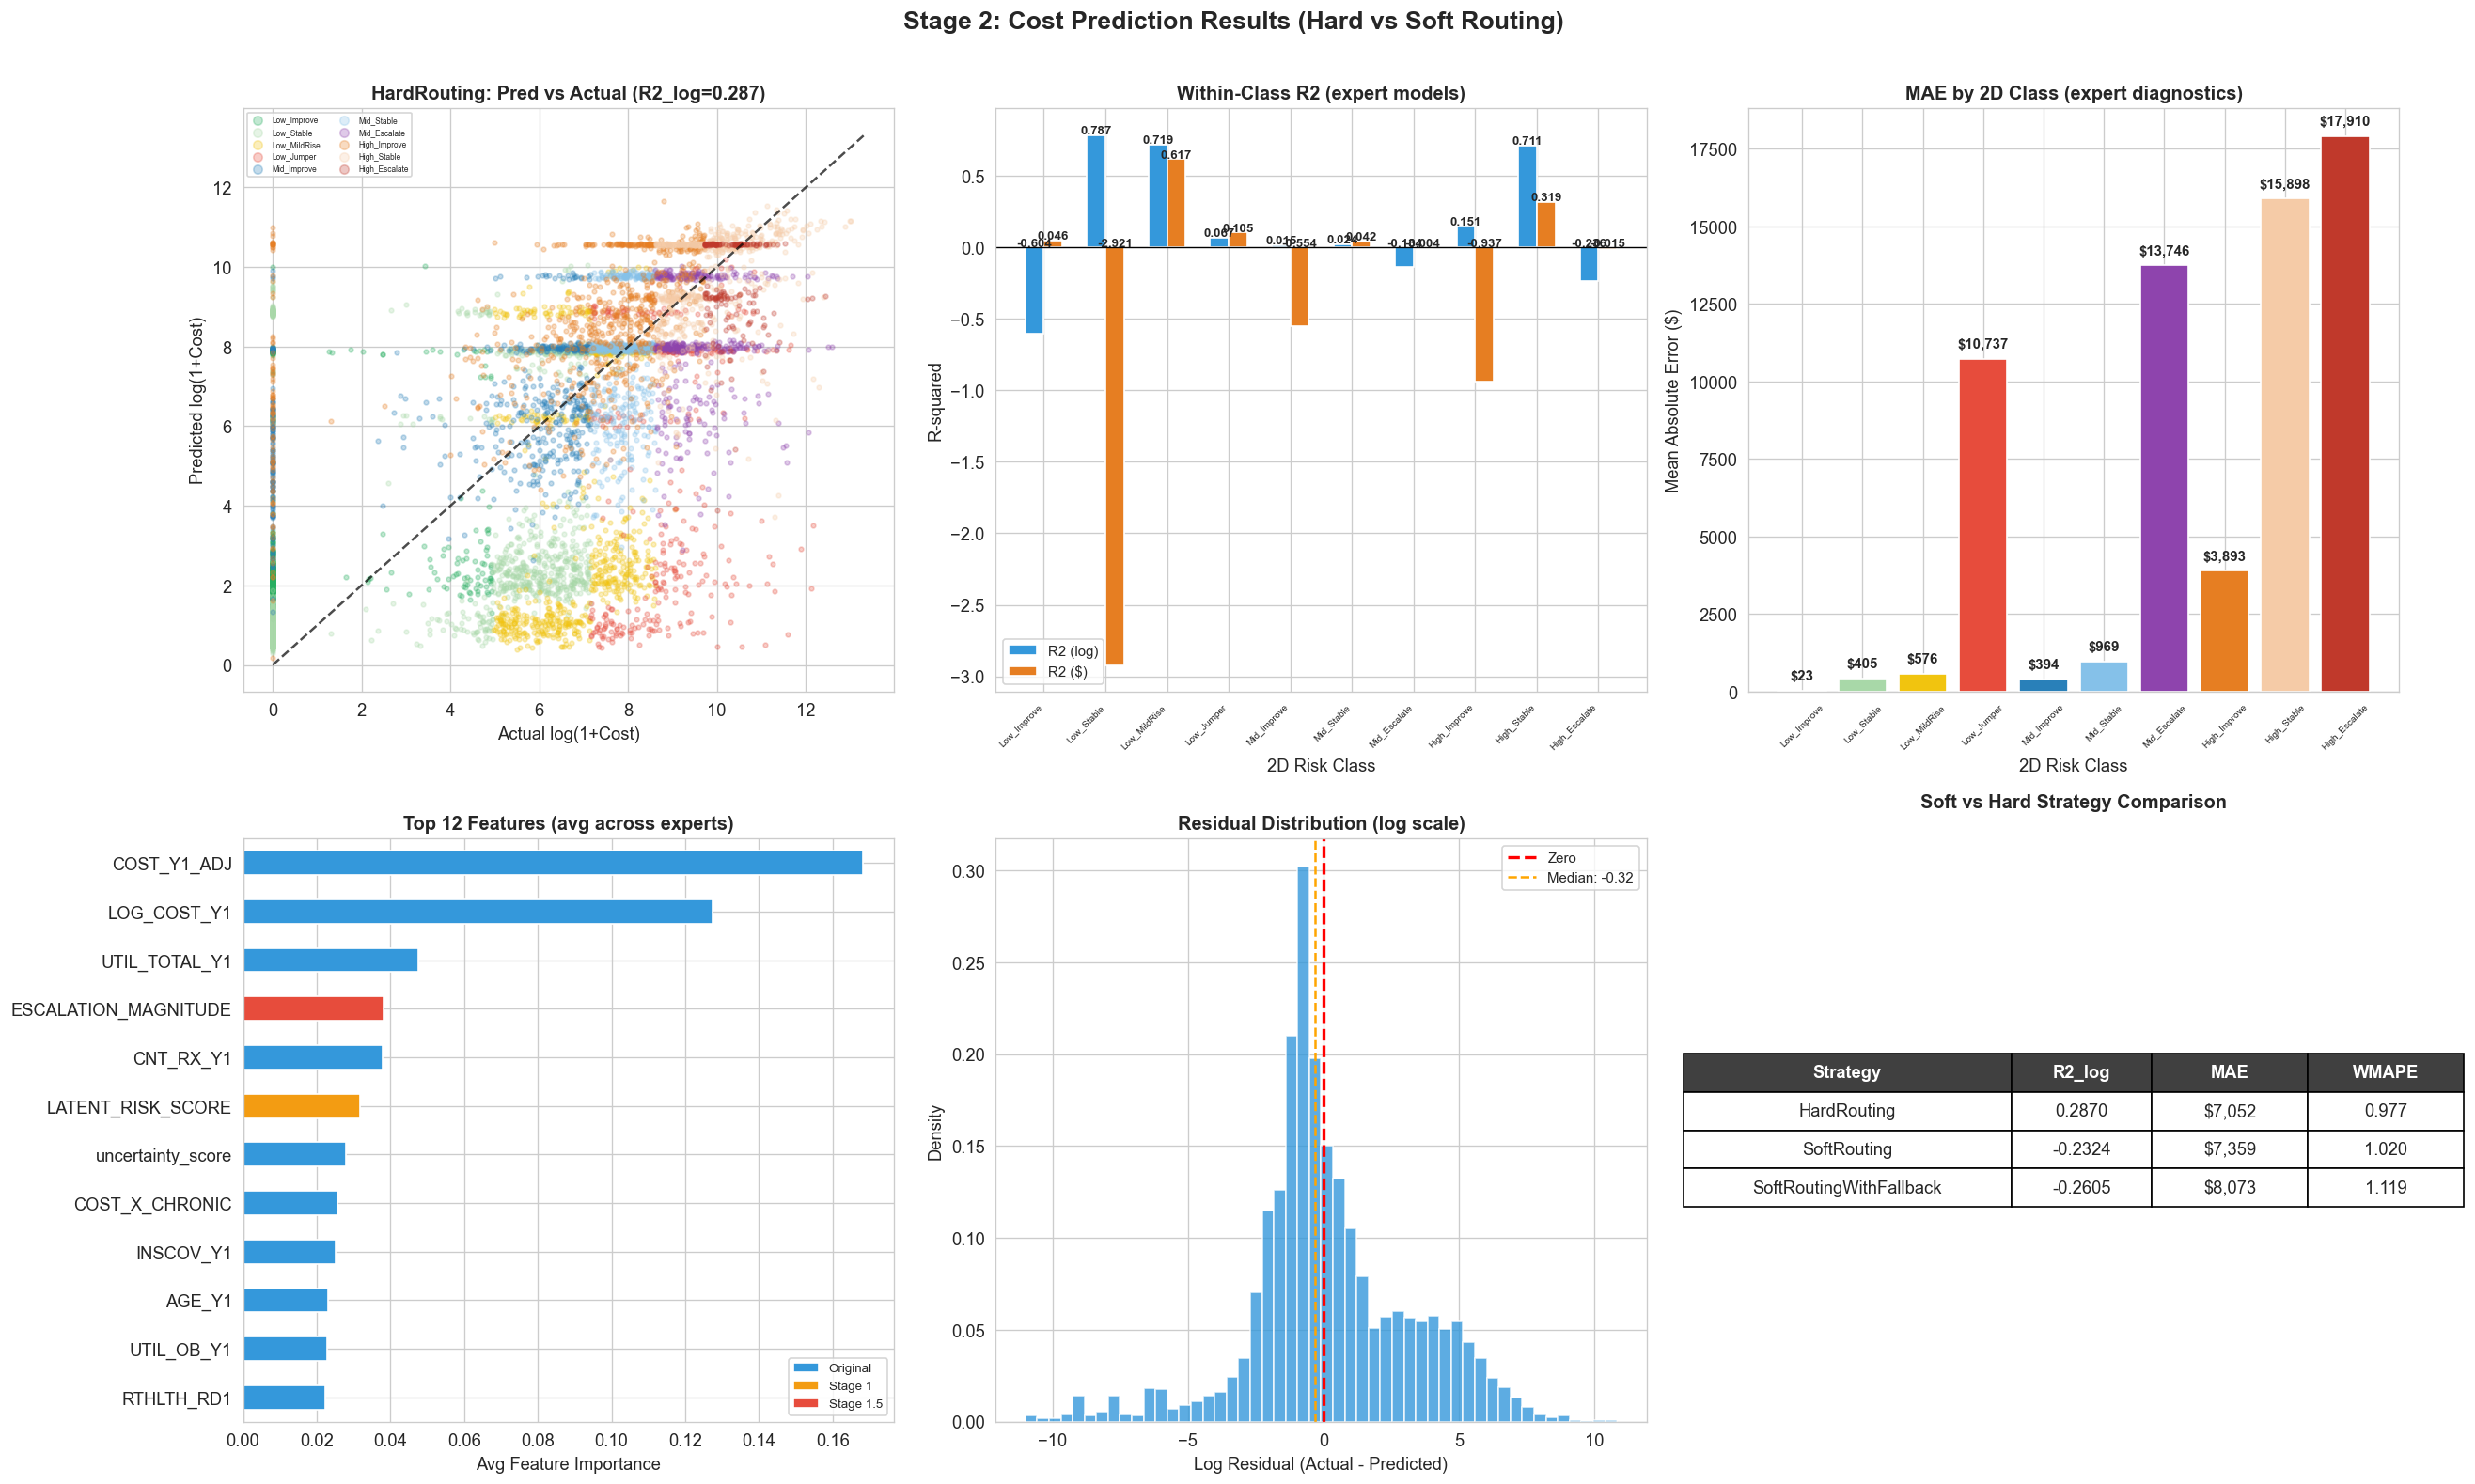

In [19]:
# VISUALIZATION: Stage 2 Results (Hard vs Soft Routing)

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('Stage 2: Cost Prediction Results (Hard vs Soft Routing)', fontsize=16, fontweight='bold', y=1.01)

trans_colors = {
    0: '#27ae60', 1: '#a8d8a8', 2: '#f1c40f', 3: '#e74c3c',
    4: '#2980b9', 5: '#85c1e9', 6: '#8e44ad',
    7: '#e67e22', 8: '#f5cba7', 9: '#c0392b',
}

# Panel 1: Pred vs Actual (selected strategy, log scale)
ax1 = axes[0, 0]
for t, tn in tier_names.items():
    m = df_test['RISK_TIER'] == t
    if m.sum() > 0:
        ax1.scatter(y_test_log[m], y_pred_test_log[m], c=trans_colors[t], alpha=0.28, s=8, label=tn)
lim = [0, max(y_test_log.max(), y_pred_test_log.max()) + 0.3]
ax1.plot(lim, lim, 'k--', lw=1.5, alpha=0.7)
ax1.set_xlabel('Actual log(1+Cost)', fontsize=11)
ax1.set_ylabel('Predicted log(1+Cost)', fontsize=11)
r2_overall = r2_score(y_test_log, y_pred_test_log)
ax1.set_title(f'{best_strategy_name}: Pred vs Actual (R2_log={r2_overall:.3f})', fontsize=12, fontweight='bold')
ax1.legend(fontsize=5, markerscale=2, ncol=2)

# Panel 2: Within-tier R2 diagnostics from class experts
ax2 = axes[0, 1]
tier_list = [tn for tn in tier_names.values() if tn in tier_models]
r2_logs = [tier_models[tn]['r2_log'] for tn in tier_list]
r2_dollars = [tier_models[tn]['r2_dollar'] for tn in tier_list]
x = np.arange(len(tier_list))
bars1 = ax2.bar(x - 0.15, r2_logs, 0.3, label='R2 (log)', color='#3498db', edgecolor='white')
bars2 = ax2.bar(x + 0.15, r2_dollars, 0.3, label='R2 ($)', color='#e67e22', edgecolor='white')
for b, v in zip(bars1, r2_logs):
    ax2.text(b.get_x() + b.get_width()/2, max(v, 0) + 0.01, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
for b, v in zip(bars2, r2_dollars):
    ax2.text(b.get_x() + b.get_width()/2, max(v, 0) + 0.01, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
ax2.axhline(y=0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(tier_list, fontsize=6, rotation=45, ha='right')
ax2.set_xlabel('2D Risk Class', fontsize=11)
ax2.set_ylabel('R-squared', fontsize=11)
ax2.set_title('Within-Class R2 (expert models)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# Panel 3: MAE by tier (expert diagnostics)
ax3 = axes[0, 2]
maes = [tier_models[tn]['mae'] for tn in tier_list]
tier_color_list = [trans_colors[k] for k, v in tier_names.items() if v in tier_models]
bars = ax3.bar(tier_list, maes, color=tier_color_list, edgecolor='white')
for b, v in zip(bars, maes):
    ax3.text(b.get_x() + b.get_width()/2, v + max(maes)*0.02, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_xlabel('2D Risk Class', fontsize=11)
ax3.set_ylabel('Mean Absolute Error ($)', fontsize=11)
ax3.set_title('MAE by 2D Class (expert diagnostics)', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=45, labelsize=6)

# Panel 4: Feature importance averaged across experts
ax4 = axes[1, 0]
all_imp = pd.DataFrame({tn: info['importance'] for tn, info in tier_models.items()})
avg_imp = all_imp.mean(axis=1).sort_values(ascending=False).head(12)
feat_colors = ['#e74c3c' if f in STAGE1_5_FEATS else '#f39c12' if f == 'LATENT_RISK_SCORE' else '#3498db' for f in avg_imp.index]
avg_imp.plot(kind='barh', ax=ax4, color=feat_colors)
ax4.set_xlabel('Avg Feature Importance', fontsize=11)
ax4.set_title('Top 12 Features (avg across experts)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
from matplotlib.patches import Patch
ax4.legend(handles=[Patch(fc='#3498db', label='Original'), Patch(fc='#f39c12', label='Stage 1'), Patch(fc='#e74c3c', label='Stage 1.5')], fontsize=8)

# Panel 5: Residual distribution (selected strategy)
ax5 = axes[1, 1]
resids_log = y_test_log - y_pred_test_log
ax5.hist(resids_log, bins=50, color='#3498db', edgecolor='white', alpha=0.8, density=True)
ax5.axvline(x=0, color='red', ls='--', lw=2, label='Zero')
ax5.axvline(x=np.median(resids_log), color='orange', ls='--', lw=1.5, label=f"Median: {np.median(resids_log):.2f}")
ax5.set_xlabel('Log Residual (Actual - Predicted)', fontsize=11)
ax5.set_ylabel('Density', fontsize=11)
ax5.set_title('Residual Distribution (log scale)', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)

# Panel 6: Strategy comparison table
ax6 = axes[1, 2]
ax6.axis('off')
overall_cmp = stage2_soft_vs_hard_df[stage2_soft_vs_hard_df['Segment'] == 'Overall'].copy()
overall_cmp = overall_cmp.sort_values('MAE')

cols = ['Strategy', 'R2_log', 'MAE', 'WMAPE']
show = overall_cmp[cols].copy()
show['R2_log'] = show['R2_log'].map(lambda x: f'{x:.4f}')
show['MAE'] = show['MAE'].map(lambda x: f'${x:,.0f}')
show['WMAPE'] = show['WMAPE'].map(lambda x: f'{x:.3f}')

table_data = [cols] + show.values.tolist()
table = ax6.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.42, 0.18, 0.20, 0.20])
table.scale(1.2, 1.8)
for i in range(len(cols)):
    table[(0, i)].set_facecolor('#404040')
    table[(0, i)].set_text_props(color='white', fontweight='bold')
ax6.set_title('Soft vs Hard Strategy Comparison', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'stage2_results.png', dpi=150, bbox_inches='tight')
plt.show()

### Stage 2 Results

**What this section is trying to prove**

Because expenditure is highly skewed, the question is not just “which regressor is best.” The real question is whether **routing by Stage 1 transition structure** helps us predict Year 2 cost more reliably than one global model.

**How to read the strategies**

- `HardRouting`: choose exactly one class-specific expert using the Stage 1 hard/policy class.
- `SoftRouting`: blend experts using the full Stage 1 probability vector. This is usually safer when Stage 1 has classification noise.
- `SoftRoutingWithFallback`: same as soft routing, but uncertain cases revert to the global model.

**Interpretation logic**

- If `SoftRouting` beats `HardRouting`, that means Stage 1 probabilities contain useful information even when the single hard class is imperfect.
- If `SoftRoutingWithFallback` helps further, uncertainty is adding value.
- If it does not help, the fallback rule is probably too blunt and is throwing away useful expert information.
- The standalone global fallback is kept only as an internal anchor. We do not headline it as a benchmark if the log-to-dollar retransformation is unstable and produces implausible errors.

In this project, the most important endpoint is **MAE in dollars**, supported by `R2_log` because log-scale fit is more stable under heavy right skew.


---
## Ablation Study: Value of Latent Factors


ABLATION STUDY


  Original Only                      : R2_log=0.1355, R2_$=0.1451, MAE=$7,084


  + Interactions                     : R2_log=0.1362, R2_$=0.1395, MAE=$7,098


  + LATENT_RISK_SCORE                : R2_log=0.1400, R2_$=0.1461, MAE=$7,050


  + Stage 1.5 Enrichment             : R2_log=0.1417, R2_$=0.1464, MAE=$7,080


  + Full Pipeline (All Features)     : R2_log=0.1439, R2_$=0.1516, MAE=$7,052


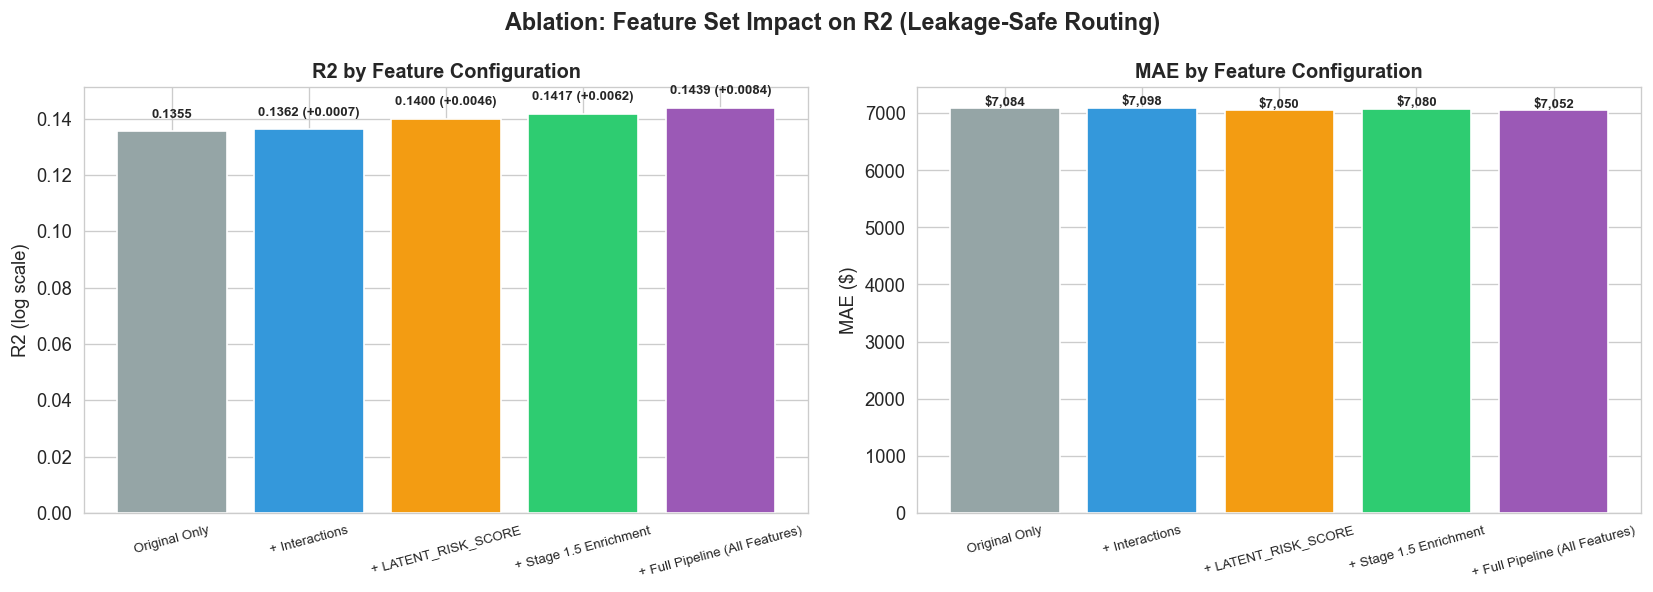

In [20]:
# Ablation: Value of Latent Factors
print('ABLATION STUDY')

def train_tier_ablation(feat_list, name):
    feats = [f for f in feat_list if f in df.columns]

    # Global fallback model (always available)
    g_model = XGBRegressor(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=3.0,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
    )
    g_model.fit(
        df_train[feats].fillna(0),
        y_train_log,
        eval_set=[(df_val[feats].fillna(0), y_val_log)],
        verbose=False,
    )
    g_train_pred = g_model.predict(df_train[feats].fillna(0))
    g_smear = np.mean(np.exp(y_train_log - g_train_pred))

    preds_log = g_model.predict(df_test[feats].fillna(0))
    preds_dollar = np.clip(np.expm1(preds_log) * g_smear, 0, None)

    # Tier overrides routed by Stage 1 predicted class
    for tv, tn in tier_names.items():
        tr_m = (df_train['RISK_TIER'].to_numpy() == tv)
        va_m = (df_val['RISK_TIER'].to_numpy() == tv)
        te_route_m = (stage1_pred_test == tv)

        if tr_m.sum() < 30 or va_m.sum() < 10:
            continue

        hp = tier_hyperparams.get(tv, tier_hyperparams[1])
        xg = XGBRegressor(
            n_estimators=hp['n_estimators'],
            max_depth=hp['max_depth'],
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=hp['reg_lambda'],
            min_child_weight=hp['min_child_weight'],
            random_state=42,
            n_jobs=-1,
            early_stopping_rounds=50,
        )
        xg.fit(
            df_train.loc[tr_m, feats].fillna(0),
            np.log1p(y_train[tr_m]),
            eval_set=[(df_val.loc[va_m, feats].fillna(0), np.log1p(y_val[va_m]))],
            verbose=False,
        )

        tr_resid = np.log1p(y_train[tr_m]) - xg.predict(df_train.loc[tr_m, feats].fillna(0))
        smear = np.mean(np.exp(tr_resid))

        if te_route_m.sum() > 0:
            p_log = xg.predict(df_test.loc[te_route_m, feats].fillna(0))
            p_dollar = np.clip(np.expm1(p_log) * smear, 0, None)
            preds_log[te_route_m] = p_log
            preds_dollar[te_route_m] = p_dollar

    r2l = r2_score(y_test_log, preds_log)
    r2d = r2_score(y_test, preds_dollar)
    mae_v = mean_absolute_error(y_test, preds_dollar)
    print(f'  {name:35s}: R2_log={r2l:.4f}, R2_$={r2d:.4f}, MAE=${mae_v:,.0f}')
    return {'Model': name, 'R2_log': r2l, 'R2_dollar': r2d, 'MAE': mae_v, 'N_feats': len(feats)}

results = []
results.append(train_tier_ablation(original_avail, 'Original Only'))
results.append(train_tier_ablation(original_avail + interact_avail, '+ Interactions'))
results.append(train_tier_ablation(original_avail + interact_avail + ['LATENT_RISK_SCORE'], '+ LATENT_RISK_SCORE'))
results.append(train_tier_ablation(original_avail + interact_avail + stage1_5_avail, '+ Stage 1.5 Enrichment'))
results.append(train_tier_ablation(TIER_FEATS, '+ Full Pipeline (All Features)'))

abl_df = pd.DataFrame(results)
abl_df['R2_log_gain'] = abl_df['R2_log'] - abl_df['R2_log'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation: Feature Set Impact on R2 (Leakage-Safe Routing)', fontsize=14, fontweight='bold')
colors = ['#95a5a6', '#3498db', '#f39c12', '#2ecc71', '#9b59b6']

ax1 = axes[0]
bars = ax1.bar(range(len(abl_df)), abl_df['R2_log'], color=colors[:len(abl_df)], edgecolor='white')
for b, v, g in zip(bars, abl_df['R2_log'], abl_df['R2_log_gain']):
    label = f'{v:.4f}' if g == 0 else f'{v:.4f} (+{g:.4f})'
    ax1.text(b.get_x() + b.get_width()/2, v + 0.005, label, ha='center', fontsize=8, fontweight='bold')
ax1.set_xticks(range(len(abl_df)))
ax1.set_xticklabels(abl_df['Model'], fontsize=8, rotation=15)
ax1.set_ylabel('R2 (log scale)', fontsize=11)
ax1.set_title('R2 by Feature Configuration', fontsize=12, fontweight='bold')

ax2 = axes[1]
bars = ax2.bar(range(len(abl_df)), abl_df['MAE'], color=colors[:len(abl_df)], edgecolor='white')
for b, v in zip(bars, abl_df['MAE']):
    ax2.text(b.get_x() + b.get_width()/2, v + 50, f'${v:,.0f}', ha='center', fontsize=8, fontweight='bold')
ax2.set_xticks(range(len(abl_df)))
ax2.set_xticklabels(abl_df['Model'], fontsize=8, rotation=15)
ax2.set_ylabel('MAE ($)', fontsize=11)
ax2.set_title('MAE by Feature Configuration', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'stage2_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
abl_df.to_csv(REPORT_DIR / 'tables' / 'stage2_model_comparison.csv', index=False)

In [21]:
# Save Output using selected Stage 2 strategy
print('Saving...')

# Full-data global prediction (fallback anchor)
full_global_log = global_xgb.predict(df[ALL_FEATS].fillna(0))
full_global_dollar = np.clip(np.expm1(full_global_log) * global_smearing, 0, None)

# Full-data Stage 1 fields
full_prob = df[stage1_prob_cols].to_numpy()
full_hard = df['pred_class_hard'].astype(int).to_numpy()
full_policy = df['pred_class_policy'].astype(int).to_numpy()
full_review = df['review_flag'].astype(int).to_numpy()
full_unc = df['uncertainty_score'].to_numpy()

# Precompute class expert predictions on full data
n_full = len(df)
full_class_pred = np.tile(full_global_dollar.reshape(-1, 1), (1, len(class_order)))
X_full_tier = df[TIER_FEATS].fillna(0)

for tier_val, tier_name in tier_names.items():
    if tier_name not in tier_models:
        continue
    mdl = tier_models[tier_name]['model']
    smear = smearing_factors.get(tier_name, 1.0)
    pred_all = np.clip(np.expm1(mdl.predict(X_full_tier)) * smear, 0, None)
    full_class_pred[:, tier_val] = pred_all

# Strategy predictions on full data
pred_full = {}

# Global
pred_full['GlobalFallback'] = {
    'dollar': full_global_dollar,
    'route_label': np.array(['GlobalFallback'] * n_full, dtype=object),
    'fallback_flag': np.ones(n_full, dtype=int),
}

# Hard routing
hard_route = full_policy.copy()
hard_missing = hard_route < 0
hard_route[hard_missing] = full_hard[hard_missing]

hard_dollar = full_global_dollar.copy()
hard_route_label = np.array(['GlobalFallback'] * n_full, dtype=object)
hard_route_label[hard_missing] = 'PolicyReviewFallback'
hard_fallback_flag = hard_missing.astype(int)

for tier_val, tier_name in tier_names.items():
    if tier_name not in tier_models:
        continue
    m = (hard_route == tier_val) & (~hard_missing)
    if m.sum() == 0:
        continue
    hard_dollar[m] = full_class_pred[m, tier_val]
    hard_route_label[m] = tier_name
    hard_fallback_flag[m] = 0

pred_full['HardRouting'] = {
    'dollar': hard_dollar,
    'route_label': hard_route_label,
    'fallback_flag': hard_fallback_flag,
}

# Soft routing
soft_dollar = np.sum(full_prob * full_class_pred, axis=1)
pred_full['SoftRouting'] = {
    'dollar': soft_dollar,
    'route_label': np.array(['SoftBlend'] * n_full, dtype=object),
    'fallback_flag': np.zeros(n_full, dtype=int),
}

# Soft + fallback
unc_cut = np.quantile(full_unc, 0.90)
soft_fb_flag = ((full_review == 1) | (full_unc >= unc_cut)).astype(int)
soft_fb_dollar = soft_dollar.copy()
soft_fb_dollar[soft_fb_flag == 1] = full_global_dollar[soft_fb_flag == 1]
soft_fb_label = np.array(['SoftBlend'] * n_full, dtype=object)
soft_fb_label[soft_fb_flag == 1] = 'SoftFallback_Global'

pred_full['SoftRoutingWithFallback'] = {
    'dollar': soft_fb_dollar,
    'route_label': soft_fb_label,
    'fallback_flag': soft_fb_flag,
}

# Select strategy fixed from test-set comparison
chosen = pred_full[best_strategy_name]
df['PREDICTED_COST_Y2'] = chosen['dollar']
df['STAGE2_STRATEGY'] = best_strategy_name
df['STAGE2_ROUTE_CLASS'] = chosen['route_label']
df['STAGE2_FALLBACK_FLAG'] = chosen['fallback_flag']

output_path = REPO_ROOT / 'data' / 'processed_v2' / 'model_ready_stage2.parquet'
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(output_path, index=False)
print(f'Saved to {output_path}: {len(df):,} rows, {len(df.columns)} cols')

print()
print('Selected strategy route distribution (full dataset):')
route_counts = pd.Series(chosen['route_label']).value_counts()
for k, v in route_counts.items():
    print(f'  {k:22s}: {v:>6,} ({v/len(df)*100:.1f}%)')

Saving...


Saved to /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/data/processed_v2/model_ready_stage2.parquet: 60,602 rows, 91 cols

Selected strategy route distribution (full dataset):
  Low_Stable            : 11,349 (18.7%)
  Low_Improve           : 10,905 (18.0%)
  High_Improve          :  7,554 (12.5%)
  Mid_Improve           :  6,377 (10.5%)
  Mid_Stable            :  6,224 (10.3%)
  Low_MildRise          :  5,665 (9.3%)
  High_Stable           :  4,172 (6.9%)
  High_Escalate         :  3,190 (5.3%)
  Mid_Escalate          :  2,964 (4.9%)
  Low_Jumper            :  2,202 (3.6%)


---
## Summary

**What Stage 2 establishes**

- Year 2 expenditure is too skewed to model well with a single undifferentiated story.
- Stage 1 provides routing structure.
- Stage 1.5 provides engineered predictors that capture care pattern, expected transition magnitude, and prescription continuity.
- The final comparison tells us whether probability-based routing is more robust than hard class assignment.

**What to report from this notebook**

1. Which routing strategy had the best held-out MAE.
2. Whether the gain came from class-specific experts, soft routing, or both.
3. Which engineered predictors repeatedly appeared near the top of expert models beyond `COST_Y1_ADJ`.

**What not to overclaim**

- A single engineered feature is not a clinical rule by itself.
- Some Stage 1.5 gains are incremental, not dramatic, and that is expected once strong baseline cost information is already present.
- The value of the pipeline is the combination of routing plus additional non-cost signal, not any one chart in isolation.
